#### Librerias

In [1]:
!pip install faiss-cpu sentence-transformers umap-learn hdbscan -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.8/23.8 MB 40.6 MB/s eta 0:00:00


In [2]:
# Librerías estándar
import json
import random
import re
import os
import warnings
from collections import Counter, defaultdict
import numpy as np
import pandas as pd
import ast
from tqdm.auto import tqdm
tqdm.pandas()
# Visualización
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.graph_objects as go

# Machine Learning
import faiss
import umap
import hdbscan
from sklearn.preprocessing import MultiLabelBinarizer

# NLP / Embeddings
from sentence_transformers import SentenceTransformer

#  API
import requests

# Advertencias
warnings.filterwarnings("ignore")
os.environ["TOKENIZERS_PARALLELISM"] = "false"

import logging
from transformers import logging as transformers_logging
from huggingface_hub import logging as hf_logging
import huggingface_hub.utils._http

transformers_logging.set_verbosity_error()
hf_logging.set_verbosity_error()
huggingface_hub.utils._http.logging.set_verbosity_error()


# 0. Data

**Descripción de datos**

**My Anime List:**
* **mal_id:** Identificador único del anime en MyAnimeList
* **rank:** Posición en el ranking general de MAL (menor = mejor)
* **title:** Título oficial del anime
* **score:** Calificación promedio dada por los usuarios (escala 1–10)
* **episodes:** Número total de episodios
* **status:** Estado de emisión (en curso, finalizado, por estrenar)
* **media_type:** Formato de la producción (TV, Movie, OVA, ONA, Special)
* **genres:** Géneros, demografías y temas asignados al anime
* **year:** Año de estreno
* **popularity:** Ranking de popularidad basado en usuarios que lo agregaron a su lista
* **synopsis:** Descripción narrativa del argumento del anime
* **studios:** Estudio(s) de animación responsables de la producción
* **rating:** Clasificación por edad (G, PG, PG-13, R, R+, Rx)
* **image_url:** URL de la imagen de portada del anime
* **related_anime:** Lista de animes relacionados (precuelas, secuelas, adaptaciones)

**TMDB**
* **tmdb_id:** Identificador único de la obra en The Movie Database
* **tipo:** Categoría de la producción (película o serie)
* **título:** Título oficial de la película o serie
* **público:** Clasificación por edad según el país de origen (G, PG, PG-13, R, TV-MA, etc.)
* **score:** Calificación promedio dada por los usuarios de TMDB (escala 1–10)
* **votos:** Número total de votos que respaldan la calificación
* **fecha:** Fecha de estreno o primera emisión
* **géneros:** Géneros asignados por TMDB (en español)
* **sinopsis:** Descripción narrativa del argumento de la obra
* **popularidad:** Puntaje de popularidad calculado por TMDB según visitas, ratings y actividad reciente
* **idioma_original:** Idioma en el que fue producida originalmente la obra
* **imagen_url:** URL de la imagen de portada de la película o serie

In [3]:
URL_ANIME  = "https://raw.githubusercontent.com/Fernanda-gr/TobiCross/main/Colab/anime.csv"

try:
    df_anime  = pd.read_csv(URL_ANIME)
    print(f"anime.csv  cargado : {df_anime.shape}")
except Exception as e:
    print(f"Error al cargar los datos: {e}")

df_anime.head()

anime.csv  cargado : (3153, 15)


,mal_id,rank,title,score,episodes,status,media_type,genres,year,popularity,synopsis,studios,rating,image_url,related_anime
0,52991,1,Sousou no Frieren,9.27,28,finished_airing,tv,"Adventure, Award Winning, Drama, Fantasy, Shounen",2023,106,During their decade-long quest to defeat the D...,Madhouse,pg_13,https://myanimelist.net/images/anime/1015/1380...,"['Yuusha', 'Sousou no Frieren: ●● no Mahou', '..."
1,5114,2,Fullmetal Alchemist: Brotherhood,9.11,64,finished_airing,tv,"Action, Adventure, Drama, Fantasy, Military, S...",2009,3,After a horrific alchemy experiment goes wrong...,Bones,r,https://myanimelist.net/images/anime/1208/9474...,"['Fullmetal Alchemist', 'Fullmetal Alchemist: ..."
2,9253,3,Steins;Gate,9.07,24,finished_airing,tv,"Drama, Psychological, Sci-Fi, Suspense, Time T...",2011,14,Eccentric scientist Rintarou Okabe has a never...,White Fox,pg_13,https://myanimelist.net/images/anime/1935/1279...,"['ChäoS;HEAd', 'Steins;Gate: Oukoubakko no Por..."
3,28977,4,Gintama°,9.05,51,finished_airing,tv,"Action, Comedy, Gag Humor, Historical, Parody,...",2015,349,"Gintoki, Shinpachi, and Kagura return as the f...",Bandai Namco Pictures,pg_13,https://myanimelist.net/images/anime/3/72078l....,"[""Gintama': Enchousen"", 'Gintama°: Umai-mono w..."
4,38524,5,Shingeki no Kyojin Season 3 Part 2,9.05,10,finished_airing,tv,"Action, Drama, Gore, Military, Shounen, Surviv...",2019,20,Seeking to restore humanity's diminishing hope...,Wit Studio,r,https://myanimelist.net/images/anime/1517/1006...,"['Shingeki no Kyojin Season 3', 'Shingeki no K..."


In [4]:
URL_PELSER = "https://raw.githubusercontent.com/Fernanda-gr/TobiCross/main/Colab/pelser.csv"

try:
    df_pelser = pd.read_csv(URL_PELSER)
    print(f"pelser.csv cargado : {df_pelser.shape}")
except Exception as e:
    print(f"Error al cargar los datos: {e}")

df_pelser.head()

pelser.csv cargado : (3217, 12)


,tmdb_id,tipo,título,público,score,votos,fecha,géneros,sinopsis,popularidad,idioma_original,imagen_url
0,1396,serie,Breaking Bad,TV-MA,8.939,17399,2008-01-20,"['Drama', 'Crimen']",Un profesor de Química de secundaria con cánce...,159.9977,en,https://image.tmdb.org/t/p/w500/ztkUQFLlC19CCM...
1,246,serie,Avatar: La leyenda de Aang,TV-Y7,8.757,4739,2005-02-21,"['Animación', 'Action & Adventure', 'Sci-Fi & ...","El mundo está dividido en cuatro naciones, cor...",38.3316,en,https://image.tmdb.org/t/p/w500/ucNtkZfpZ6Kgxq...
2,94605,serie,Arcane,TV-14,8.753,5772,2021-11-06,"['Animación', 'Action & Adventure']",Mientras la discordia separa las ciudades geme...,50.2418,en,https://image.tmdb.org/t/p/w500/i1vSPUbiBe2iK2...
3,278,película,Sueño de fuga,B,8.717,29995,1994-09-23,"['Drama', 'Crimen']",Andy Dufresne es un banquero injustamente enca...,50.7884,en,https://image.tmdb.org/t/p/w500/l6V3TEoJlGh3zt...
4,60059,serie,Better Call Saul,TV-MA,8.704,6306,2015-02-08,"['Crimen', 'Drama']",La acción se ubica en el año 2002 en torno al ...,107.3543,en,https://image.tmdb.org/t/p/w500/zjg4jpK1Wp2kiR...


### Utilidades

In [5]:
## LImpia el texto para que sea legible
def limpiar_titulo_base(titulo):
    titulo = titulo.lower()

    titulo = re.sub(r'[\(\[].*?[\)\]]', '', titulo)

    basura = [
        'movie', 'ova', 'ona', 'special', 'specials',
        'season', 'part', 'episode', 'tv', 'movies',
        'the', 'a', 'an',
    ]
    for b in basura:
        titulo = re.sub(rf'\b{b}\b', '', titulo, flags=re.IGNORECASE)

    titulo = re.sub(r'\b\d+\b', '', titulo)

    titulo = re.sub(r'[:\-\.]\s+.*', '', titulo)

    titulo = re.sub(r'[^a-z0-9 ]', '', titulo)
    titulo = re.sub(r'\s+', ' ', titulo).strip()

    palabras = titulo.split()
    return " ".join(palabras[:2])

In [6]:
## Convierte cualquier valor a set de forma segura, eliminando errores de formato
def to_set(val):
    if not val:                return set()
    if isinstance(val, list):  return set(val)
    if isinstance(val, str):   return {val}
    return set()


In [7]:
## Evita que vectores largos dominen la similitud
def norm(v):
    n = np.linalg.norm(v)
    return v / n if n > 0 else v

# 1. EDA

#### Estadísticas de resumen

In [8]:
# My Anime List
df_anime.info()
df_anime.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3153 entries, 0 to 3152
Data columns (total 15 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   mal_id         3153 non-null   int64  
 1   rank           3153 non-null   int64  
 2   title          3153 non-null   object 
 3   score          3022 non-null   float64
 4   episodes       3153 non-null   int64  
 5   status         3153 non-null   object 
 6   media_type     3153 non-null   object 
 7   genres         3152 non-null   object 
 8   year           3153 non-null   int64  
 9   popularity     3153 non-null   int64  
 10  synopsis       3074 non-null   object 
 11  studios        3014 non-null   object 
 12  rating         3106 non-null   object 
 13  image_url      3113 non-null   object 
 14  related_anime  3113 non-null   object 
dtypes: float64(1), int64(5), object(9)
memory usage: 369.6+ KB


,mal_id,rank,score,episodes,year,popularity
count,3153.000000,3153.000000,3022.000000,3153.000000,3153.000000,3153.000000
mean,28622.203298,385.236283,7.742237,13.105297,2013.993657,4549.826197
std,21054.680816,521.992342,0.572440,37.127973,9.260573,5137.758307
min,1.000000,1.000000,4.710000,0.000000,1969.000000,1.000000
25%,6713.000000,130.000000,7.360000,1.000000,2009.000000,701.000000
50%,31859.000000,259.000000,7.730000,3.000000,2016.000000,3061.000000
75%,48569.000000,402.000000,8.150000,13.000000,2021.000000,6256.000000
max,63773.000000,2991.000000,9.270000,720.000000,2026.000000,29685.000000


In [9]:
# TMDB
df_pelser.info()
df_pelser.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3217 entries, 0 to 3216
Data columns (total 12 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   tmdb_id          3217 non-null   int64  
 1   tipo             3217 non-null   object 
 2   título           3217 non-null   object 
 3   público          2449 non-null   object 
 4   score            3217 non-null   float64
 5   votos            3217 non-null   int64  
 6   fecha            3217 non-null   object 
 7   géneros          3217 non-null   object 
 8   sinopsis         3053 non-null   object 
 9   popularidad      3217 non-null   float64
 10  idioma_original  3217 non-null   object 
 11  imagen_url       3217 non-null   object 
dtypes: float64(2), int64(2), object(8)
memory usage: 301.7+ KB


,tmdb_id,score,votos,popularidad
count,3.217000e+03,3217.000000,3217.000000,3217.000000
mean,1.649114e+05,7.447167,4058.481194,18.672126
std,2.489539e+05,0.514381,4871.114176,37.252710
min,1.100000e+01,4.818000,500.000000,0.125700
25%,4.011000e+03,7.070000,1221.000000,4.439900
50%,5.001400e+04,7.400000,2042.000000,7.606700
75%,2.485070e+05,7.800000,4689.000000,16.018400
max,1.376434e+06,8.939000,39217.000000,523.189700


In [10]:
##Cambio de object a numerico la columna year
df_anime['year'] = pd.to_numeric(df_anime['year'], errors='coerce').fillna(0).astype(int)

In [11]:
## Extracción del año
df_pelser['year'] = pd.to_datetime(
    df_pelser['fecha'], errors='coerce'
).dt.year.fillna(0).astype(int)

df_pelser = df_pelser.drop(columns=['fecha'])

#### Visualización de datos

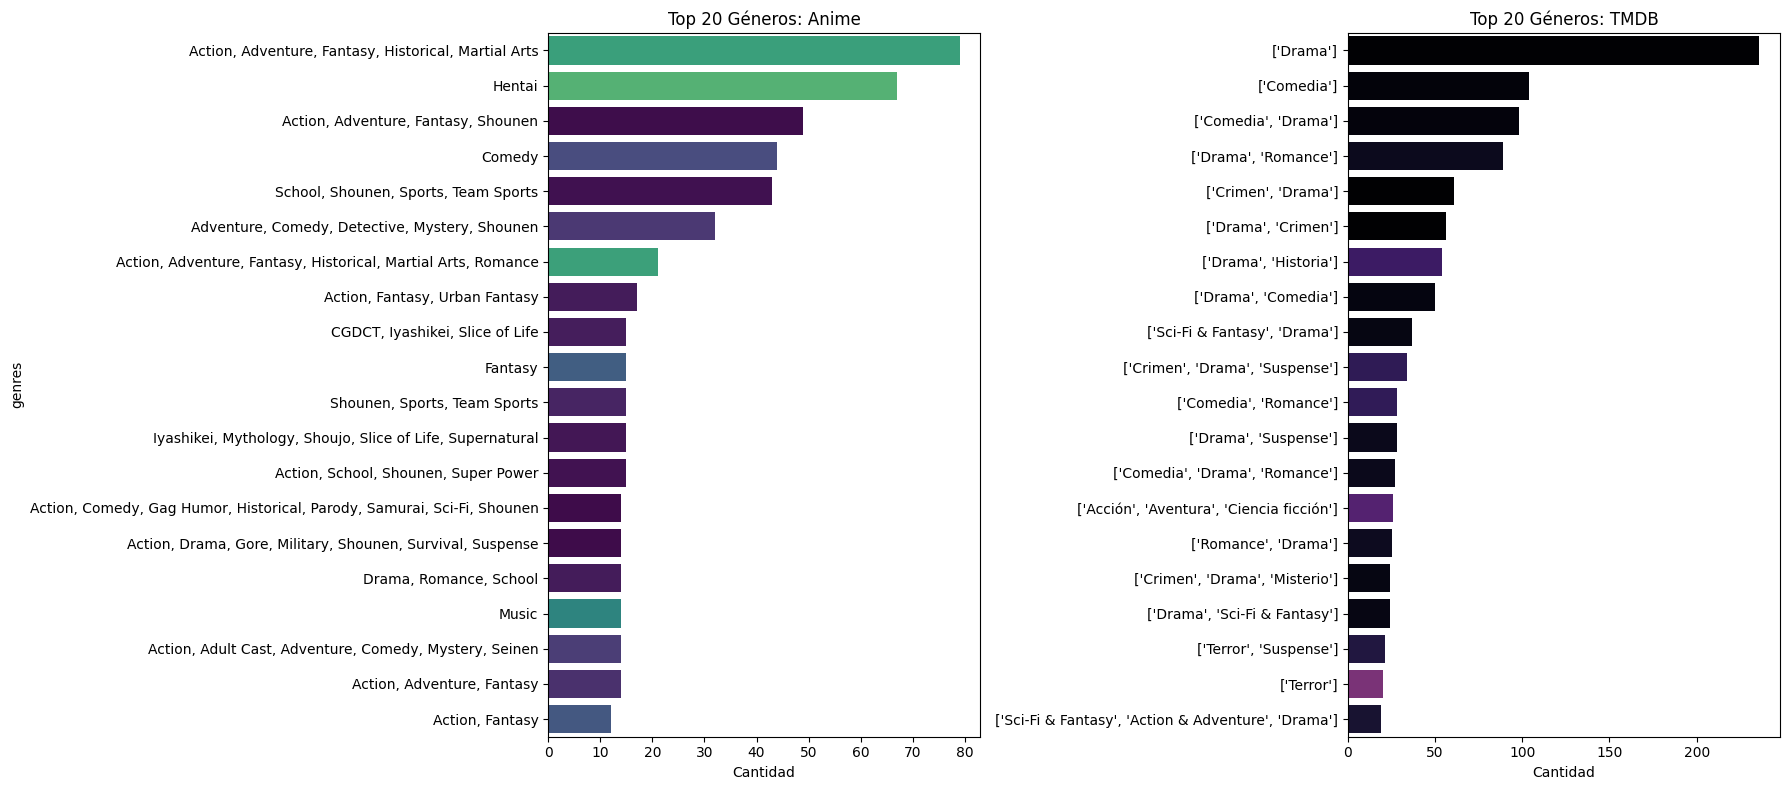

In [12]:
## Comparativa de la frecuencia o distribución de géneros:
df_plot_anime = df_anime.explode('genres')
df_plot_pelser = df_pelser.explode('géneros')


fig, axes = plt.subplots(1, 2, figsize=(18, 8))

# MAL
sns.countplot(
    data=df_plot_anime,
    y='genres',
    hue='genres',
    order=df_plot_anime['genres'].value_counts().iloc[:20].index,
    palette='viridis',
    legend=False,
    ax=axes[0]
)
axes[0].set_title('Top 20 Géneros: Anime')
axes[0].set_xlabel('Cantidad')

#  TMDB
sns.countplot(
    data=df_plot_pelser,
    y='géneros',
    hue='géneros',
    order=df_plot_pelser['géneros'].value_counts().iloc[:20].index,
    palette='magma',
    legend=False,
    ax=axes[1]
)
axes[1].set_title('Top 20 Géneros: TMDB')
axes[1].set_xlabel('Cantidad')
axes[1].set_ylabel('')

plt.tight_layout()
plt.show()





*   En MAL hay combinación de demografias (¿a quién va dirigido?), géneros (¿de qué trata?), themes (¿qué mensaje tiene?).
*   TMDB separa las categorías, existe redundancia en los géneros.
* Falta crear diccionario de mapeo para que ambos idiomas coincidad.

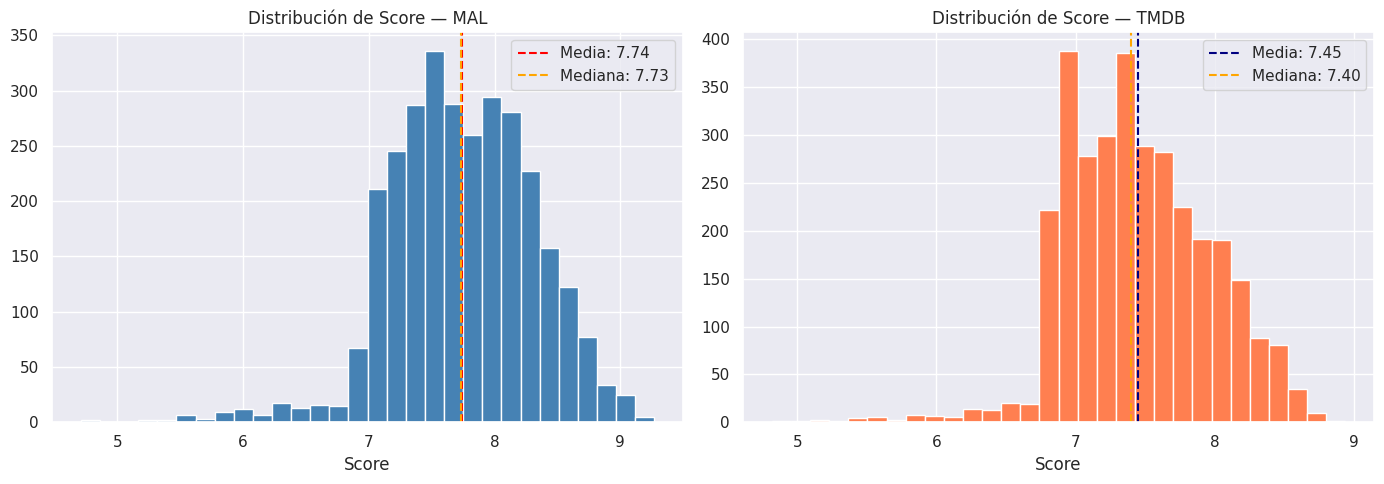

MAL  — min: 4.71  max: 9.27  std: 0.57
TMDB — min: 4.82  max: 8.94  std: 0.51


In [13]:
## Comparar la distribución de las calificaciones:
sns.set_theme(style='darkgrid', palette='muted')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# MAL
axes[0].hist(df_anime['score'], bins=30, color='steelblue', edgecolor='white')
axes[0].axvline(df_anime['score'].mean(), color='red', linestyle='--',
                label=f"Media: {df_anime['score'].mean():.2f}")
axes[0].axvline(df_anime['score'].median(), color='orange', linestyle='--',
                label=f"Mediana: {df_anime['score'].median():.2f}")
axes[0].set_title('Distribución de Score — MAL')
axes[0].set_xlabel('Score')
axes[0].legend()

# TMDB
axes[1].hist(df_pelser['score'], bins=30, color='coral', edgecolor='white')
axes[1].axvline(df_pelser['score'].mean(), color='navy', linestyle='--',
                label=f"Media: {df_pelser['score'].mean():.2f}")
axes[1].axvline(df_pelser['score'].median(), color='orange', linestyle='--',
                label=f"Mediana: {df_pelser['score'].median():.2f}")
axes[1].set_title('Distribución de Score — TMDB')
axes[1].set_xlabel('Score')
axes[1].legend()

plt.tight_layout()
plt.show()

print(f"MAL  — min: {df_anime['score'].min():.2f}  max: {df_anime['score'].max():.2f}  std: {df_anime['score'].std():.2f}")
print(f"TMDB — min: {df_pelser['score'].min():.2f}  max: {df_pelser['score'].max():.2f}  std: {df_pelser['score'].std():.2f}")

Los datos tienen una distribución simetrica, no existen colas largas que arruinen el promedio.

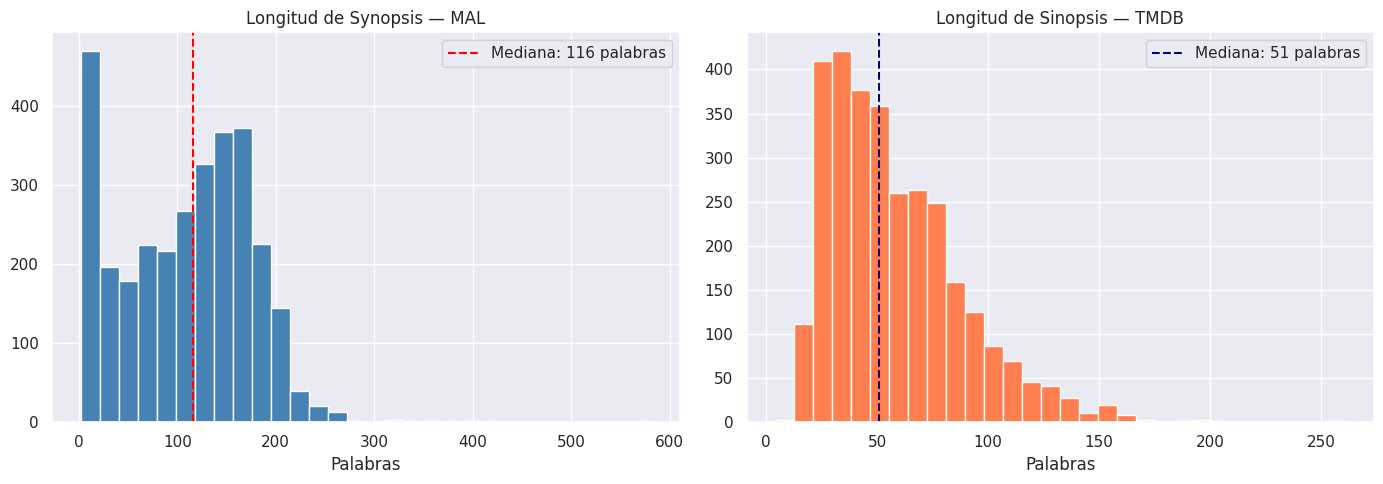

MAL  — min: 2.0  max: 581.0  mediana: 116
TMDB — min: 4.0  max: 261.0  mediana: 51


In [14]:
## Distribución de la longitud de las sinopsis

df_anime['synopsis_len']  = df_anime['synopsis'].str.split().str.len()
df_pelser['sinopsis_len'] = df_pelser['sinopsis'].str.split().str.len()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(df_anime['synopsis_len'], bins=30, color='steelblue', edgecolor='white')
axes[0].axvline(df_anime['synopsis_len'].median(), color='red', linestyle='--',
                label=f"Mediana: {df_anime['synopsis_len'].median():.0f} palabras")
axes[0].set_title('Longitud de Synopsis — MAL')
axes[0].set_xlabel('Palabras')
axes[0].legend()

axes[1].hist(df_pelser['sinopsis_len'], bins=30, color='coral', edgecolor='white')
axes[1].axvline(df_pelser['sinopsis_len'].median(), color='navy', linestyle='--',
                label=f"Mediana: {df_pelser['sinopsis_len'].median():.0f} palabras")
axes[1].set_title('Longitud de Sinopsis — TMDB')
axes[1].set_xlabel('Palabras')
axes[1].legend()

plt.tight_layout()
plt.show()

print(f"MAL  — min: {df_anime['synopsis_len'].min()}  max: {df_anime['synopsis_len'].max()}  mediana: {df_anime['synopsis_len'].median():.0f}")
print(f"TMDB — min: {df_pelser['sinopsis_len'].min()}  max: {df_pelser['sinopsis_len'].max()}  mediana: {df_pelser['sinopsis_len'].median():.0f}")



*   TMDB cuenta con sinopsis más génericas (menos detalladas)
*   MAL cuenta con descripciones detalladas, nombre de personajes y tramas.

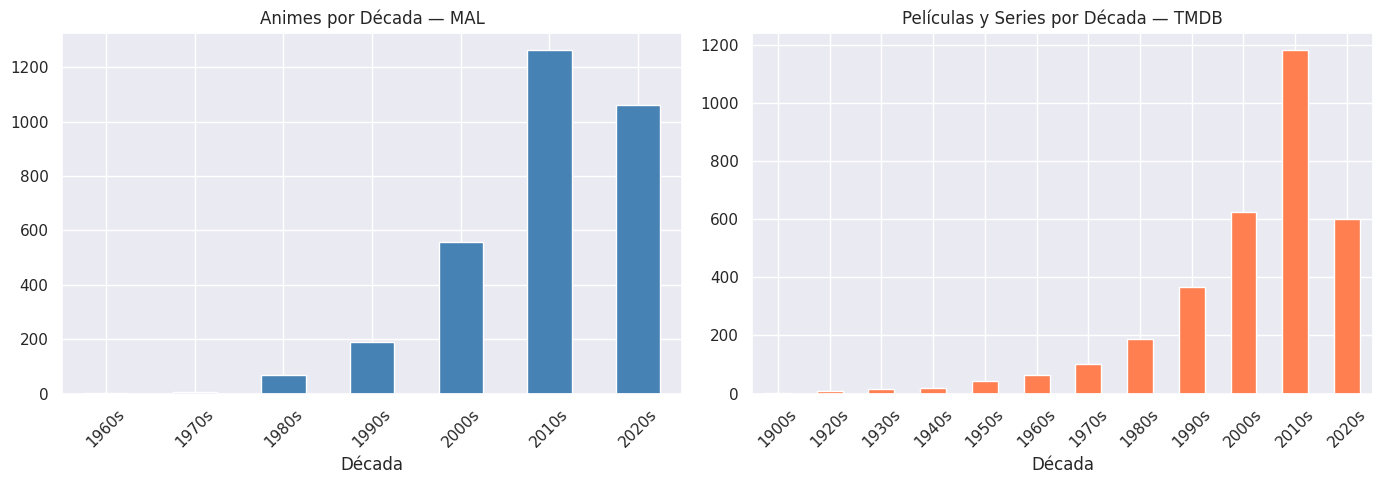

In [15]:
## Distribución de títulos por década
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# MAL por década
df_anime_years = df_anime[df_anime['year'] > 0].copy()
df_anime_years['decada'] = (df_anime_years['year'] // 10 * 10).astype(str) + 's'
decade_counts = df_anime_years['decada'].value_counts().sort_index()
decade_counts.plot(kind='bar', ax=axes[0], color='steelblue', edgecolor='white')
axes[0].set_title('Animes por Década — MAL')
axes[0].set_xlabel('Década')
axes[0].tick_params(axis='x', rotation=45)

# TMDB por década
df_pelser_years = df_pelser[df_pelser['year'] > 0].copy()
df_pelser_years['decada'] = (df_pelser_years['year'] // 10 * 10).astype(str) + 's'
decade_counts_tmdb = df_pelser_years['decada'].value_counts().sort_index()
decade_counts_tmdb.plot(kind='bar', ax=axes[1], color='coral', edgecolor='white')
axes[1].set_title('Películas y Series por Década — TMDB')
axes[1].set_xlabel('Década')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

*  La época de los 2010s tiene la mayor cantidad de datos.
*  MAL es mas moderno, mientras TMDB cuenta con datos de peliculas y series clásicas.

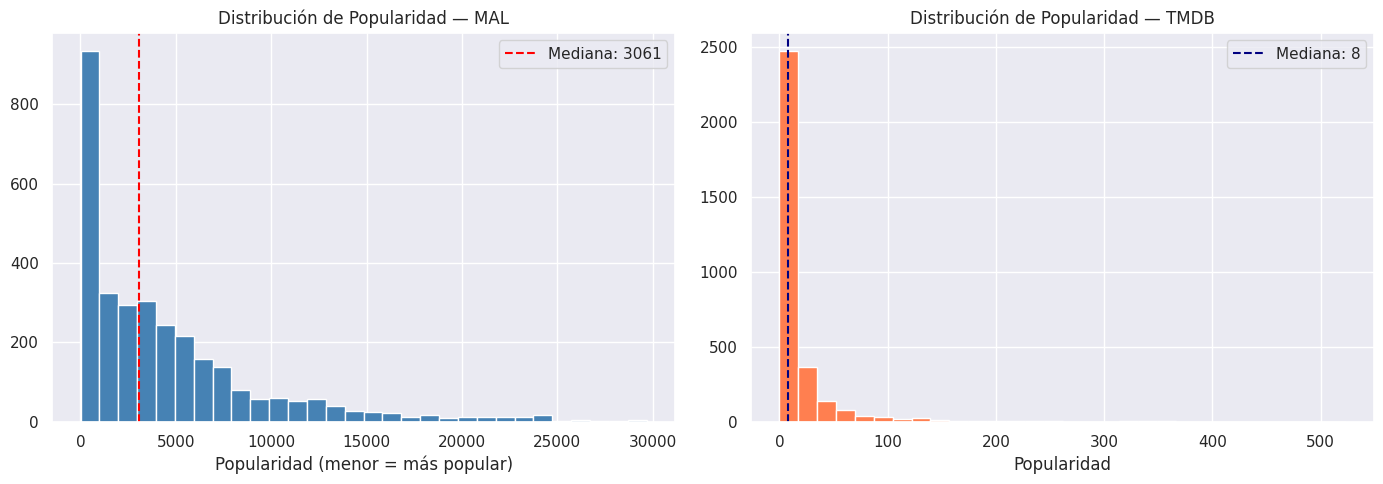

MAL  — min: 1  max: 29685
TMDB — min: 0.1  max: 523.2


In [16]:
## Comparativa de Métricas de Popularidad
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# MAL (menor rank = más popular)
axes[0].hist(df_anime['popularity'], bins=30, color='steelblue', edgecolor='white')
axes[0].axvline(df_anime['popularity'].median(), color='red', linestyle='--',
                label=f"Mediana: {df_anime['popularity'].median():.0f}")
axes[0].set_title('Distribución de Popularidad — MAL')
axes[0].set_xlabel('Popularidad (menor = más popular)')
axes[0].legend()

# TMDB
axes[1].hist(df_pelser['popularidad'], bins=30, color='coral', edgecolor='white')
axes[1].axvline(df_pelser['popularidad'].median(), color='navy', linestyle='--',
                label=f"Mediana: {df_pelser['popularidad'].median():.0f}")
axes[1].set_title('Distribución de Popularidad — TMDB')
axes[1].set_xlabel('Popularidad')
axes[1].legend()

plt.tight_layout()
plt.show()

print(f"MAL  — min: {df_anime['popularity'].min()}  max: {df_anime['popularity'].max()}")
print(f"TMDB — min: {df_pelser['popularidad'].min():.1f}  max: {df_pelser['popularidad'].max():.1f}")



*   En MAL entre más pequeño sea el número, mayor es la popularidad.
*   MAL tiene la capacidad de distinguir la popularidad, TMDB las peliculas y series pueden tener la misma popularidad.

####  Detección de valores atípicos

##### My Anime List

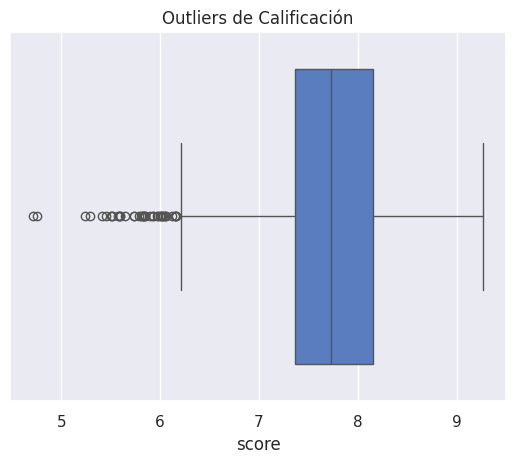

In [17]:
# Ver outliers en el Score (calificación)
sns.boxplot(x=df_anime['score'])
plt.title('Outliers de Calificación')
plt.show()

In [18]:
## Método intercuartilico para analizar outliers
Q1 = df_anime['score'].quantile(0.25)
Q3 = df_anime['score'].quantile(0.75)
IQR = Q3 - Q1

# Definir límites
limite_inferior = Q1 - 1.5 * IQR
limite_superior = Q3 + 1.5 * IQR

# Identificar los registros que son outliers
outliers = df_anime[(df_anime['score'] < limite_inferior) | (df_anime['score'] > limite_superior)]
print(f"Se encontraron {len(outliers)} outliers en el Score.")

Se encontraron 42 outliers en el Score.


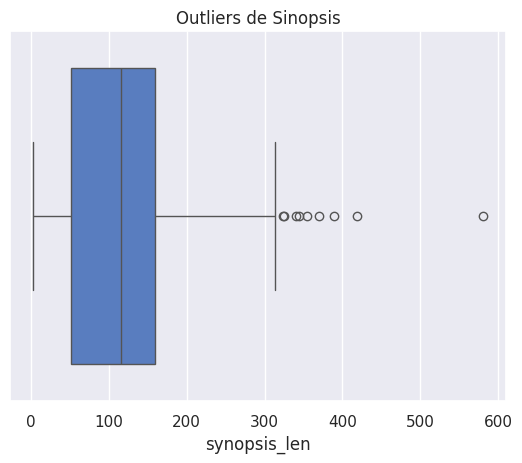

In [19]:
# Ver outliers en sinopsis
sns.boxplot(x=df_anime['synopsis_len'])
plt.title('Outliers de Sinopsis')
plt.show()

In [20]:
## Método intercuartilico para analizar outliers
Q1 = df_anime['synopsis_len'].quantile(0.25)
Q3 = df_anime['synopsis_len'].quantile(0.75)
IQR = Q3 - Q1

# Definir límites
limite_inferior = Q1 - 1.5 * IQR
limite_superior = Q3 + 1.5 * IQR

# Identificar los registros que son outliers
outliers = df_anime[(df_anime['synopsis_len'] < limite_inferior) | (df_anime['synopsis_len'] > limite_superior)]
print(f"Se encontraron {len(outliers)} outliers en Sinopsis.")

Se encontraron 9 outliers en Sinopsis.


###### Tratamiento

In [21]:
#  Filtro por Títulos
palabras_hentai = ['breeder', 'immoral', 'sukebe', 'gal ni', 'imaizumin', 'tsukawasete']
pattern_titulos = '|'.join(palabras_hentai)
df_anime = df_anime[~df_anime['title'].str.contains(pattern_titulos, case=False, na=False)]

# Filtro por Géneros
df_anime = df_anime[~df_anime['genres'].str.contains('Hentai|Erotica', case=False, na=False)]


In [22]:
# Eliminar PV, CM, Music
df_anime = df_anime[~df_anime['media_type'].isin(['pv', 'cm', 'music'])]

# Eliminar score < 5.5 (conserva Boruto, Yami Shibai, etc.)
df_anime = df_anime[df_anime['score'] >= 5.5]

print(f"Anime restantes: {len(df_anime)}")

Anime restantes: 2930


Se eliminaron titulos para +18
Se elimino aquellos que son pv, cm y music ya que no aportan mucho al recomendador
se conservaron unicamente scores arriba de 5.5, para que las recomendaciones sean buenas.
Las sinopsis no necesitan ttratamiento ya que aportan demasiada informacion al recomendador

##### TMDB

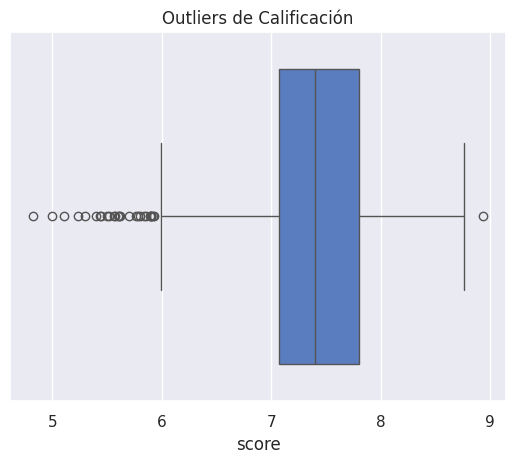

In [23]:
# Ver outliers en el Score (calificación)
sns.boxplot(x=df_pelser['score'])
plt.title('Outliers de Calificación')
plt.show()

In [24]:
## Método intercuartilico para analizar outliers
Q1 = df_pelser['score'].quantile(0.25)
Q3 = df_pelser['score'].quantile(0.75)
IQR = Q3 - Q1

# Definir límites inferior y superior
limite_inferior = Q1 - 1.5 * IQR
limite_superior = Q3 + 1.5 * IQR

# Identificar los registros que son outliers
outliers = df_pelser[(df_pelser['score'] < limite_inferior) |
                       (df_pelser['score'] > limite_superior)]

print(f"Se encontraron {len(outliers)} outliers en Score.")


Se encontraron 28 outliers en Score.


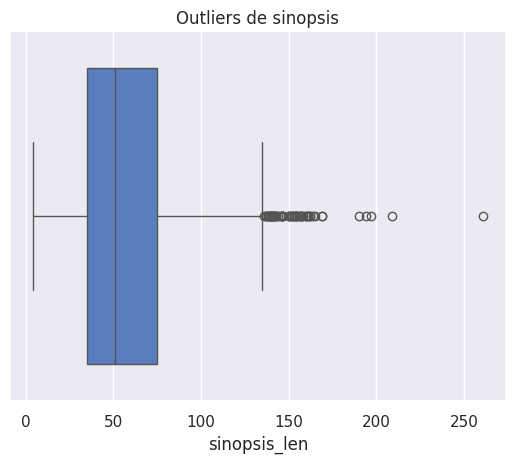

In [25]:
# Ver outliers en Votos
sns.boxplot(x=df_pelser['sinopsis_len'])
plt.title('Outliers de sinopsis')
plt.show()

In [26]:
## Método intercuartilico para analizar outliers
Q1 = df_pelser['sinopsis_len'].quantile(0.25)
Q3 = df_pelser['sinopsis_len'].quantile(0.75)
IQR = Q3 - Q1

# Definir límites inferior y superior
limite_inferior = Q1 - 1.5 * IQR
limite_superior = Q3 + 1.5 * IQR

# Identificar los registros que son outliers
outliers = df_pelser[(df_pelser['sinopsis_len'] < limite_inferior) |
                       (df_pelser['sinopsis_len'] > limite_superior)]

print(f"Se encontraron {len(outliers)} outliers en Sinopsis.")

Se encontraron 62 outliers en Sinopsis.


###### Tratamiento

En df_pelser las películas son el punto de partida (query), no el resultado. El flujo es:
película (query) → busca similitud → recomienda anime
Entonces:

Score bajo → no importa, una persona que vio Resident Evil y le gustó merece recomendaciones igual
Pocos votos → no importa, el modelo no usa votos para calcular similitud
Popularidad extrema → no importa, no entra al vector

Los outliers dañan cuando están en la variable que el modelo usa para aprender o comparar. Aquí votos, score y popularidad de películas no entran a ningún vector, por lo tanto son irrelevantes para el modelo.
Lo único que sí importa tratar son los nulos de sinopsis y público porque esas sí generan embedding y demog_vector respectivamente. Un nulo ahí produce un vector vacío o erróneo.

#### Valores Faltantes

##### My Anime List

In [27]:
## Duplicados
antes = len(df_anime)
df_anime = df_anime.drop_duplicates(subset='mal_id').reset_index(drop=True)
print(f"Duplicados eliminados: {antes - len(df_anime)}")

Duplicados eliminados: 355


In [28]:
df_anime.isnull().sum()

,0
mal_id,0
rank,0
title,0
score,0
episodes,0
status,0
media_type,0
genres,1
year,0
popularity,0


In [29]:
# Al afectar la interfaz, se decidio eliminar aquellas filas sin información de imagen
df_anime= df_anime.dropna(subset=['image_url'])

In [30]:
# Moda de 'rating' para cada 'media_type'
moda= df_anime.groupby('media_type')['rating'].apply(lambda x: x.mode().iloc[0]).to_dict()

# Si el rating es nulo, busca la moda de su tipo
df_anime['rating'] = df_anime['rating'].fillna(df_anime['media_type'].map(moda))


In [31]:
# Identificamos si la sinopsis menciona que es independiente para studio
def imputar_estudio(fila):
    if pd.isna(fila['studios']):
        if fila['media_type'] in ['music', 'ona']:
            return "['Independent/Self-Produced']"
        return "['Unknown/Small Circle']"
    return fila['studios']


df_anime['studios'] = df_anime.apply(imputar_estudio, axis=1)


In [32]:
# Al ser solo 1 nulo, se procedio a eliminarlo
df_anime= df_anime.dropna(subset=['genres'])

In [33]:
## Limpieza del texto de sinopsis
def clean_text(text):
    if not isinstance(text, str):
        return ""
    text = re.sub(r'<[^>]+>', '', text)
    text = re.sub(r'\[Written by.*?\]', '', text, flags=re.IGNORECASE)
    text = re.sub(r'\s+', ' ', text)
    return text.strip()

df_anime['synopsis'] = df_anime['synopsis'].apply(clean_text)

In [34]:
## Eliminar sinopsis vacias, para que el recomendador no tenga puntos ciegos
antes = len(df_anime)
df_anime = df_anime[df_anime['synopsis'].str.len() > 30].reset_index(drop=True)
print(f"Filas eliminadas por synopsis vacía: {antes - len(df_anime)}")

Filas eliminadas por synopsis vacía: 54


In [35]:
# Rellenar con la mediana según el género (tomando el primer género de la lista)
df_anime['score'] = df_anime['score'].fillna(df_anime.groupby('genres')['score'].transform('median'))


In [36]:
# Para aquellas donde los datos no fueron suficientes para calcular la mediana, se usa la mediana de todo el dataset
mediana_global = df_anime['score'].median()
df_anime['score'] = df_anime['score'].fillna(mediana_global)

In [37]:
df_anime.isnull().sum()

,0
mal_id,0
rank,0
title,0
score,0
episodes,0
status,0
media_type,0
genres,0
year,0
popularity,0


##### TMDB

In [38]:
df_pelser.isnull().sum()

,0
tmdb_id,0
tipo,0
título,0
público,768
score,0
votos,0
géneros,0
sinopsis,164
popularidad,0
idioma_original,0


In [39]:
## Limpieza de sinopsis
df_pelser['sinopsis'] = df_pelser['sinopsis'].apply(clean_text)

In [40]:
## Sinopsis vacias
antes = len(df_pelser)
df_pelser = df_pelser[df_pelser['sinopsis'].str.len() > 30].reset_index(drop=True)
print(f"Filas eliminadas por sinopsis vacía: {antes - len(df_pelser)}")

Filas eliminadas por sinopsis vacía: 164


In [41]:
# Rellenamos basándonos en la clasificación más frecuente para esos géneros
df_pelser['público'] = df_pelser['público'].fillna(df_pelser.groupby('géneros')['público'].transform(lambda x: x.mode()[0] if not x.mode().empty else "Desconocido"))


In [42]:
df_pelser.isnull().sum()

,0
tmdb_id,0
tipo,0
título,0
público,0
score,0
votos,0
géneros,0
sinopsis,0
popularidad,0
idioma_original,0


#### Análisis de correlación

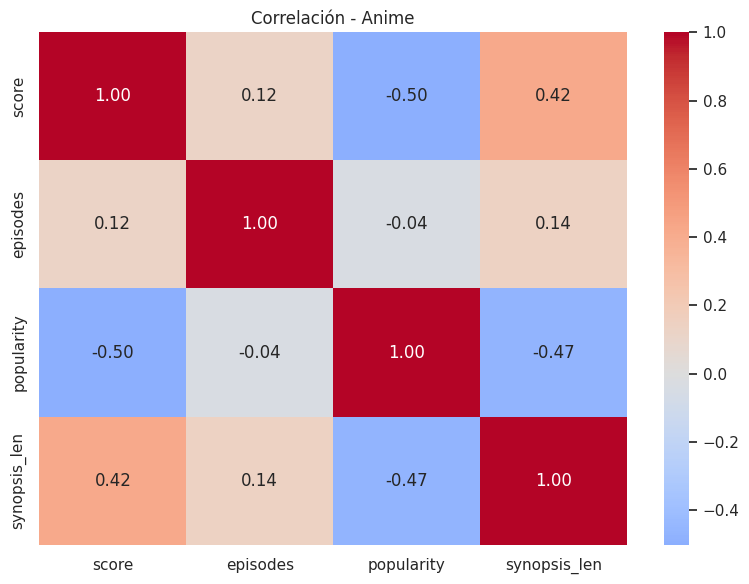

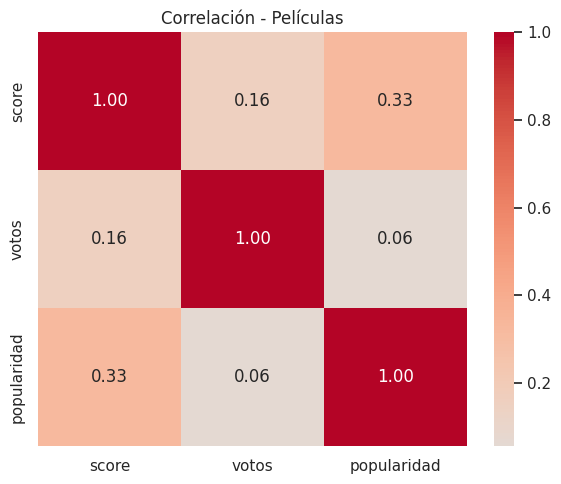

In [43]:
# ANIME
cols_anime = ['score', 'episodes', 'popularity', 'synopsis_len']
corr_anime = df_anime[cols_anime].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr_anime, annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Correlación - Anime')
plt.tight_layout()
plt.show()

# PELÍCULAS
cols_pelser = ['score', 'votos', 'popularidad']
corr_pelser = df_pelser[cols_pelser].corr()

plt.figure(figsize=(6, 5))
sns.heatmap(corr_pelser, annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Correlación - Películas')
plt.tight_layout()
plt.show()




*   En Anime, existe una correlación negativa, los números de popularidad más bajos suelen representar el ranking #1, #2, etc.
*   En las peliculas la correlación es positiva, pero más debil. Esto es, la popularidad y la calificación van de la mano.
* La cantidad de caítulos apenas influye en el score, ed decir, un anime de 12 episodios tiene las mismas probabilidades de ser bien calificado que uno de 500 episodios.
* Por otro lado, una pelicula que tenga muchos votos no garantiza que su score sea alto.



#### Estandarización de tipo de datos

##### My anime List

In [44]:
## Cambio de generos de string a lista
df_anime['genres'] = (
    df_anime['genres']
    .str.split(',')
    .apply(lambda gs: [g.strip() for g in gs if g.strip()])
)

In [45]:
## Lista
df_anime['related_anime'] = df_anime['related_anime'].apply(
    lambda x: x if isinstance(x, list) else []
)

##### TMDB

In [46]:
## Convertir a listas
df_pelser['géneros'] = df_pelser['géneros'].apply(lambda x: ast.literal_eval(x) if isinstance(x, str) else x)

#### Reconocimiento de patrones

In [47]:
# Géneros únicos en MAL
mal_genres = Counter(g for gs in df_anime['genres'] for g in gs)
print("Géneros en MAL:")
for g in sorted(mal_genres.keys()):
    print(f"  {g}")

Géneros en MAL:
  Action
  Adult Cast
  Adventure
  Anthropomorphic
  Avant Garde
  Award Winning
  Boys Love
  CGDCT
  Childcare
  Combat Sports
  Comedy
  Crossdressing
  Delinquents
  Detective
  Drama
  Ecchi
  Educational
  Fantasy
  Gag Humor
  Girls Love
  Gore
  Gourmet
  Harem
  High Stakes Game
  Historical
  Horror
  Idols (Female)
  Idols (Male)
  Isekai
  Iyashikei
  Josei
  Kids
  Love Polygon
  Love Status Quo
  Magical Sex Shift
  Mahou Shoujo
  Martial Arts
  Mecha
  Medical
  Military
  Music
  Mystery
  Mythology
  Organized Crime
  Otaku Culture
  Parody
  Performing Arts
  Pets
  Psychological
  Racing
  Reincarnation
  Reverse Harem
  Romance
  Samurai
  School
  Sci-Fi
  Seinen
  Shoujo
  Shounen
  Showbiz
  Slice of Life
  Space
  Sports
  Strategy Game
  Super Power
  Supernatural
  Survival
  Suspense
  Team Sports
  Time Travel
  Urban Fantasy
  Vampire
  Video Game
  Villainess
  Visual Arts
  Workplace


In [48]:
# Géneros únicos en TMDB
tmdb_genres = Counter(g for gs in df_pelser['géneros'] for g in gs)
print("Géneros en TMDB:")
for g in sorted(tmdb_genres.keys()):
    print(f"  {g}")

Géneros en TMDB:
  Acción
  Action & Adventure
  Animación
  Aventura
  Bélica
  Ciencia ficción
  Comedia
  Crimen
  Documental
  Drama
  Familia
  Fantasía
  Historia
  Kids
  Misterio
  Música
  News
  Película de TV
  Reality
  Romance
  Sci-Fi & Fantasy
  Soap
  Suspense
  Talk
  Terror
  War & Politics
  Western


In [49]:
## Contar cuantas filas hay de cada género
counter_anime= Counter(g for gs in df_anime["genres"] for g in gs)
print(counter_anime.most_common(30))

[('Action', 889), ('Comedy', 859), ('Shounen', 701), ('Fantasy', 623), ('Drama', 599), ('Adventure', 590), ('School', 483), ('Romance', 461), ('Sci-Fi', 402), ('Supernatural', 323), ('Mystery', 302), ('Historical', 294), ('Seinen', 276), ('Adult Cast', 239), ('Military', 162), ('Martial Arts', 150), ('Suspense', 146), ('Sports', 144), ('Super Power', 130), ('Slice of Life', 129), ('Mecha', 127), ('Music', 125), ('Psychological', 120), ('Award Winning', 114), ('Mythology', 114), ('Shoujo', 112), ('Ecchi', 93), ('Parody', 91), ('Gore', 90), ('Isekai', 87)]


In [50]:
## Contar cuantas filas hay de cada género
counter_pelser = Counter(g for gs in df_pelser["géneros"] for g in gs)
print(counter_pelser.most_common(30))

[('Drama', 1785), ('Comedia', 882), ('Suspense', 562), ('Crimen', 552), ('Acción', 476), ('Aventura', 467), ('Familia', 390), ('Romance', 368), ('Animación', 366), ('Misterio', 354), ('Sci-Fi & Fantasy', 321), ('Ciencia ficción', 283), ('Fantasía', 270), ('Action & Adventure', 248), ('Terror', 204), ('Historia', 171), ('Bélica', 96), ('Música', 67), ('Kids', 59), ('Western', 58), ('Documental', 28), ('Soap', 25), ('War & Politics', 16), ('Película de TV', 10), ('Reality', 6), ('Talk', 3), ('News', 1)]


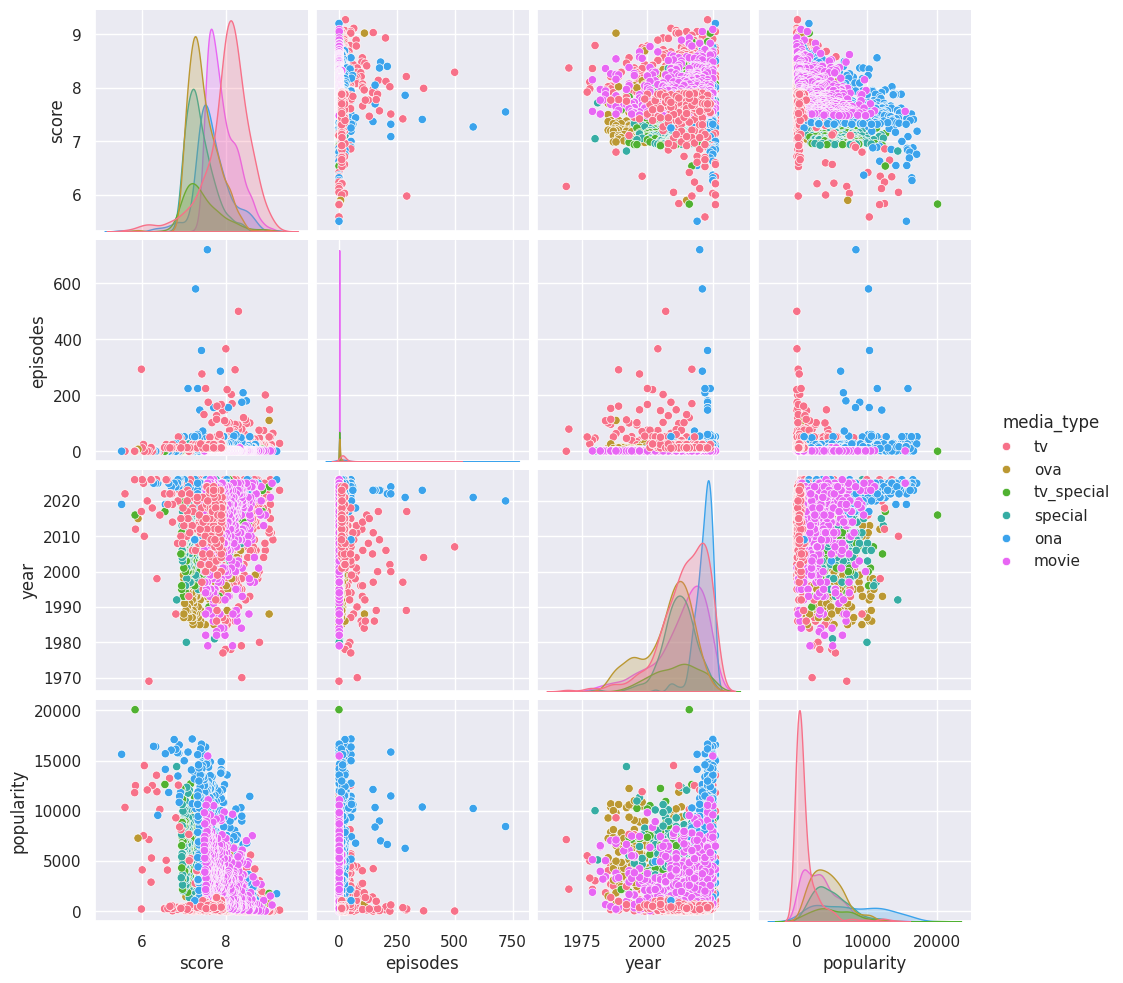

In [51]:
## Matriz de dispersion para reconocer patrones
columnas_interes = ['score', 'episodes', 'year', 'popularity', 'media_type']

# Creamos la matriz cruzada
sns.pairplot(df_anime[columnas_interes],
             hue='media_type',
             palette='husl',
             diag_kind='kde')

plt.show()



*   A medida que aumenta el score, la popularidad tiende a mejorar.
*   Producciones de TV y Movie dominan las califificaciones altas, mientras que los ONA y Special están mas dispersos.
* Las series de TV son las únicas que presentan valores extraños, esto se debe a que son producciones que superan los 200 episodios
* El formato ONA refleja el auge de las plataformas de streaming en años actuales.



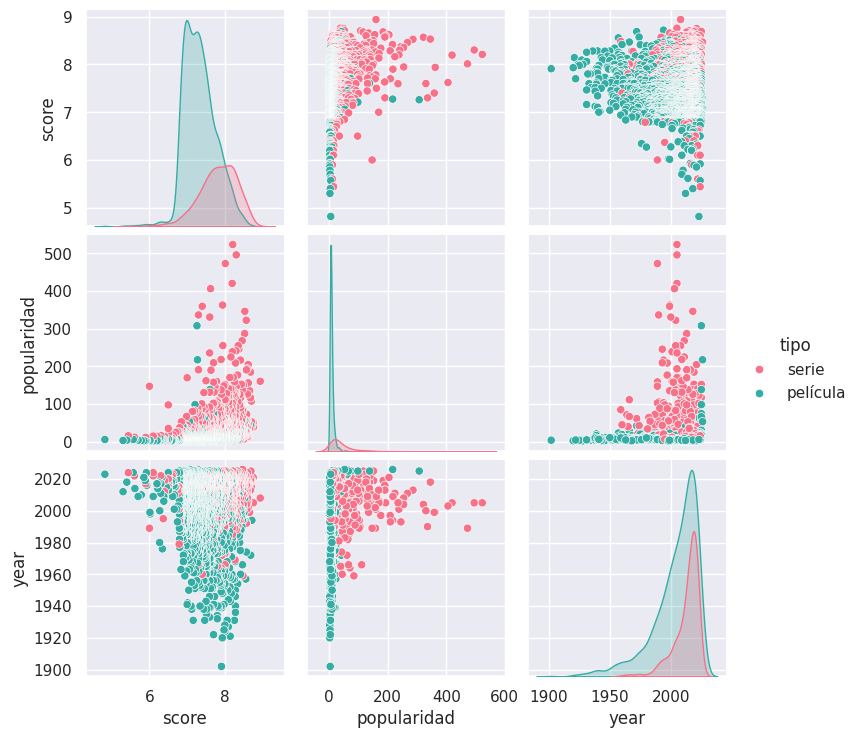

In [52]:
## Matriz de dispersión para reconocer patrones
columnas_interes = ['score', 'popularidad', 'year', 'tipo']

# Creamos la matriz cruzada
sns.pairplot(df_pelser[columnas_interes],
             hue='tipo',
             palette='husl',
             diag_kind='kde')

plt.show()



*   Las peliculas tienen una distribución de calificación más alta, la mayoria se concentra alrededor de 7-7.5. MIentras que las series muestran una variedad de calidad, existen series o muy buenas o muy malas.
*   Las series logran alcanzar picos de popularidad que las peliculas rara vez tocan. Por ejemplo, las series con puntajes altos disparan la popularidad de forma más agresiva que las peliculas con el mismo puntaje.
* Observamos la diferencia de años, mientras las series son formatos más actuales a partir de los año 70, las peliculas tienen producciones cinematográficas desde 1900-190.
* Otra cosa que se puede ver, las series conforme pasan los años su popularidad tiende a subir.



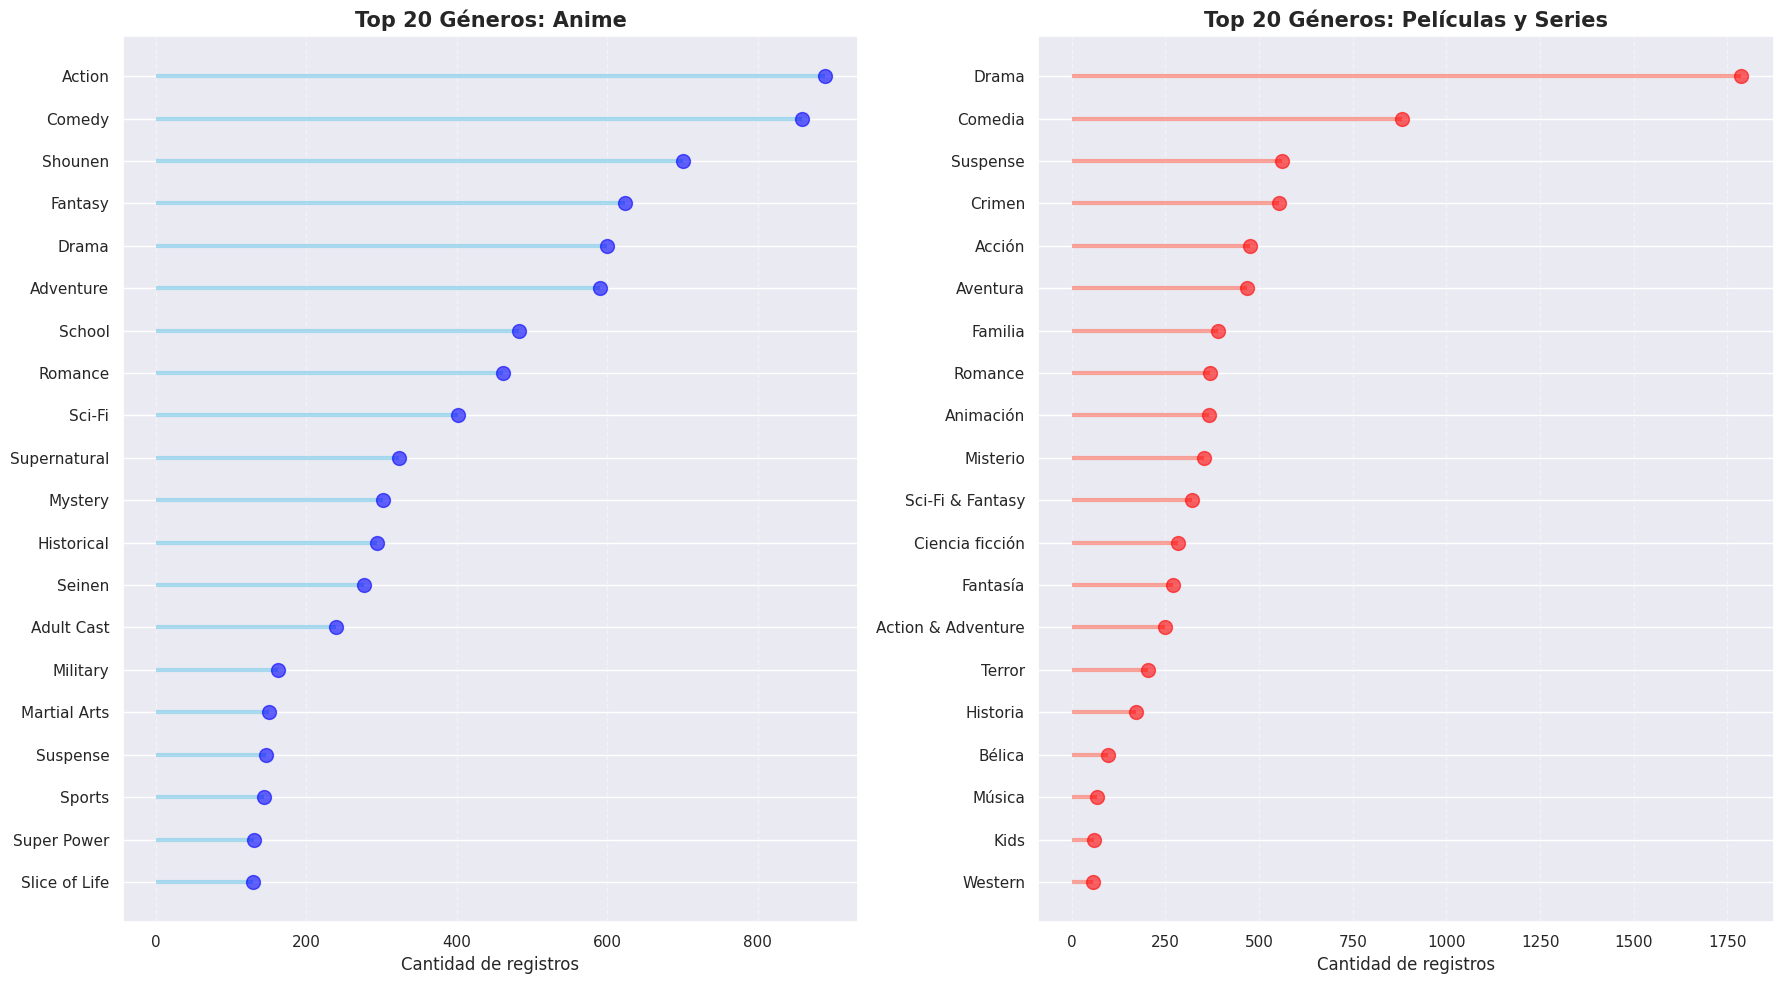

In [53]:
### Distribución de géneros
# Datos de Anime
etiquetas_anime, valores_anime = zip(*counter_anime.most_common(20))
y_pos_anime = range(len(etiquetas_anime))

# Datos de Películas/Series
etiquetas_pelser, valores_pelser = zip(*counter_pelser.most_common(20))
y_pos_pelser = range(len(etiquetas_pelser))
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 10), sharex=False)

# Anime
ax1.hlines(y=y_pos_anime, xmin=0, xmax=valores_anime, color='skyblue', alpha=0.7, linewidth=3)
ax1.plot(valores_anime, y_pos_anime, "o", markersize=10, color='blue', alpha=0.6)
ax1.set_yticks(y_pos_anime)
ax1.set_yticklabels(etiquetas_anime)
ax1.set_title('Top 20 Géneros: Anime', fontsize=15, fontweight='bold')
ax1.set_xlabel('Cantidad de registros')
ax1.invert_yaxis()
ax1.grid(axis='x', linestyle='--', alpha=0.4)

# Películas y Series
ax2.hlines(y=y_pos_pelser, xmin=0, xmax=valores_pelser, color='salmon', alpha=0.7, linewidth=3)
ax2.plot(valores_pelser, y_pos_pelser, "o", markersize=10, color='red', alpha=0.6)
ax2.set_yticks(y_pos_pelser)
ax2.set_yticklabels(etiquetas_pelser)
ax2.set_title('Top 20 Géneros: Películas y Series', fontsize=15, fontweight='bold')
ax2.set_xlabel('Cantidad de registros')
ax2.invert_yaxis()
ax2.grid(axis='x', linestyle='--', alpha=0.4)


plt.tight_layout()
plt.show()



*   En peliculas y series, el drama suele ser el género con calificaciones más estables, mientras que en series, la accion y la comedia varian y suelen ser los animes mas vistos.
*   La fantasia y la aventura ocupan posiciones similares.




#### Hallazgos de EDA

**Hallazgos clave:**

*   MAL mezcla géneros, demografías y temas en una sola columna, mientras que TMDB separa categorías con redundancia y en español, lo que requirió un trabajo de normalización posterior.
*   Ambos datasets presentan distribuciones de score simétricas (sin colas largas), lo que indica que el promedio es representativo y no será distorsionado por valores extremos.
* Las sinopsis de MAL son significativamente más detalladas (nombres de personajes, tramas específicas) que las de TMDB, que son más genéricas. Esto impacta directamente en la calidad de los embeddings semánticos.
* Se aplicó el método IQR para detectar outliers en score y longitud de sinopsis. Para MAL se encontraron outliers en ambas variables, mientras que para TMDB se justificó no tratarlos porque score y votos no entran al vector de similitud.
* El EDA reveló diferencias estructurales profundas entre los dos datasets (idioma, granularidad, convenciones de género). Estas diferencias dictaron toda la estrategia de Feature Engineering posterior.



# 2. Feature Engineering

In [54]:
print(f"df_anime  : {df_anime.shape}")
print(f"df_pelser : {df_pelser.shape}")
print(f"\nColumnas df_anime  : {df_anime.columns.tolist()}")
print(f"Columnas df_pelser : {df_pelser.columns.tolist()}")

df_anime  : (2484, 16)
df_pelser : (3053, 13)

Columnas df_anime  : ['mal_id', 'rank', 'title', 'score', 'episodes', 'status', 'media_type', 'genres', 'year', 'popularity', 'synopsis', 'studios', 'rating', 'image_url', 'related_anime', 'synopsis_len']
Columnas df_pelser : ['tmdb_id', 'tipo', 'título', 'público', 'score', 'votos', 'géneros', 'sinopsis', 'popularidad', 'idioma_original', 'imagen_url', 'year', 'sinopsis_len']


##### My anime List

In [55]:
## Separación de géneros, demografía y temas de los animes para un mejor control
GENRES = {
    'Action', 'Adventure', 'Comedy', 'Drama', 'Fantasy',
    'Romance', 'Sci-Fi', 'Supernatural', 'Mystery',
    'Historical', 'Suspense', 'Sports', 'Slice of Life',
    'Psychological', 'Horror', 'Music'
}
DEMOGRAPHIC = {
    'Shounen', 'Seinen', 'Shoujo', 'Josei', 'Kids'
}
THEMES = {
    'Adult Cast', 'Anthropomorphic', 'Avant Garde',
    'Award Winning', 'Boys Love', 'CGDCT', 'Childcare',
    'Combat Sports', 'Crossdressing', 'Delinquents',
    'Detective', 'Educational', 'Erotica', 'Gag Humor',
    'Girls Love', 'Gore', 'Gourmet', 'Harem', 'Hentai',
    'High Stakes Game', 'Idols (Female)', 'Idols (Male)',
    'Isekai', 'Iyashikei', 'Love Polygon',
    'Love Status Quo', 'Magical Sex Shift',
    'Mahou Shoujo', 'Martial Arts', 'Mecha', 'Medical',
    'Military', 'Mythology', 'Organized Crime',
    'Otaku Culture', 'Parody', 'Performing Arts',
    'Pets', 'Racing', 'Reincarnation', 'Reverse Harem',
    'Samurai', 'School', 'Showbiz', 'Space',
    'Strategy Game', 'Super Power', 'Survival',
    'Team Sports', 'Time Travel', 'Urban Fantasy',
    'Vampire', 'Video Game', 'Villainess',
    'Visual Arts', 'Workplace', 'Ecchi'
}

In [56]:
def clasificar_generos(lista):
    genres, demo, themes = [], [], []

    for g in lista:
        if g in GENRES:
            genres.append(g)
        elif g in DEMOGRAPHIC:
            demo.append(g)
        else:
            themes.append(g)

    return genres, demo, themes

df_anime[["genres_base", "demographic", "themes"]] = df_anime["genres"].apply(
    lambda x: pd.Series(clasificar_generos(x)))

In [57]:
### Elegimos los temas más importantes
THEMES_IMPORTANTES = {
    "Isekai",
    "Reincarnation",
    "Time Travel",
    "Psychological",
    "Gore",
    "Military",
    "School",
    "Organized Crime",
    "Detective",
    "Super Power",
    "Survival",
    "Space",
    "Mecha",
    "Urban Fantasy",
    "Martial Arts"
}
### Los temas importantes, lo utilizamos para convertirlo en el género correspondiente
THEME_TO_GENRE = {
    "Isekai": ["Fantasy"],
    "Reincarnation": ["Fantasy"],
    "Urban Fantasy": ["Fantasy"],

    "Time Travel": ["Sci-Fi"],
    "Space": ["Sci-Fi"],
    "Mecha": ["Sci-Fi"],

    "Gore": ["Horror"],
    "Survival": ["Suspense"],

    "Detective": ["Mystery", "Crime"],
    "Organized Crime": ["Crime"],

    "Military": ["Military"],

    "School": ["Slice of Life"],

    "Martial Arts": ["Action"],
    "Super Power": ["Action"],

    "Psychological": ["Psychological"],
}

In [58]:
## Se limpia el 'ruido' de los temas secundarios para quedarnos unicamente con una columna más limpia y funcional para el modelo.
def limpiar_anime(genres, themes):
    salida = []
    for g in genres:
        salida.append(g)

    for t in themes:
        if t in THEMES_IMPORTANTES and t in THEME_TO_GENRE:
            salida.extend(THEME_TO_GENRE[t])

    return list(set(salida))

df_anime["genres_clean"] = df_anime.apply(
    lambda row: limpiar_anime(row["genres_base"], row["themes"]),
    axis=1)

In [59]:
df_anime["genres_clean"].explode().value_counts()

,count
genres_clean,
Action,924
Comedy,859
Fantasy,631
Drama,599
Adventure,590
Slice of Life,577
Romance,461
Sci-Fi,441
Supernatural,323


In [60]:
## Se crea un diccionario que servira para rellenar la demografia de aquellos animes que están vacios.
THEME_TO_DEMOG = {
    'Gore': 'Seinen', 'Organized Crime': 'Seinen', 'Psychological': 'Seinen',
    'Adult Cast': 'Seinen', 'Workplace': 'Seinen', 'Military': 'Seinen',

    'Super Power': 'Shounen', 'Martial Arts': 'Shounen', 'Isekai': 'Shounen',
    'Samurai': 'Shounen', 'Mecha': 'Shounen',

    'Mahou Shoujo': 'Shoujo', 'Reverse Harem': 'Shoujo',
    'Boys Love': 'Shoujo', 'Girls Love': 'Shoujo',

    'Childcare': 'Josei',

    'Educational': 'Kids', 'Pets': 'Kids'
}

In [61]:
## Se creo una función para rellenar los espacios vacios.
## 1. Se respea los ya existentes
## 2. Se buscan palabras clave en los títulos
## 3. Se utiliza el diccionario
## 4. Si no encuentra, busca combinación de géneros
def inferir_demografia_unificada(row):
    if len(row['demographic']) > 0:
        return row['demographic']

    title = str(row['title']).lower()
    gen = set(row['genres_clean'])
    themes = row.get('themes', [])


    if any(x in title for x in ['grisaia', 'higurashi', 'kara no kyoukai']):
        return ['Seinen']
    if 'conan' in title:
        return ['Shounen']
    if any(x in title for x in ['arrietty', 'momoko']):
        return ['Kids']


    for t in themes:
        if t in THEME_TO_DEMOG:
            return [THEME_TO_DEMOG[t]]


    if {'Psychological', 'Horror', 'Mystery'} & gen:
        return ['Seinen']

    if {'Action', 'Adventure', 'Sports', 'Sci-Fi'} & gen:
        return ['Shounen']

    if 'Romance' in gen:
        if 'Slice of Life' in gen:
            return ['Shoujo']
        return ['Shoujo']

    if 'Slice of Life' in gen and len(gen) == 1:
        return ['Kids']


    return ['Shounen']

df_anime['demographic'] = df_anime.apply(inferir_demografia_unificada, axis=1)

In [62]:
df_anime

,mal_id,rank,title,score,episodes,status,media_type,genres,year,popularity,synopsis,studios,rating,image_url,related_anime,synopsis_len,genres_base,demographic,themes,genres_clean
0,52991,1,Sousou no Frieren,9.27,28,finished_airing,tv,"[Adventure, Award Winning, Drama, Fantasy, Sho...",2023,106,During their decade-long quest to defeat the D...,Madhouse,pg_13,https://myanimelist.net/images/anime/1015/1380...,[],174.0,"[Adventure, Drama, Fantasy]",[Shounen],[Award Winning],"[Fantasy, Adventure, Drama]"
1,5114,2,Fullmetal Alchemist: Brotherhood,9.11,64,finished_airing,tv,"[Action, Adventure, Drama, Fantasy, Military, ...",2009,3,After a horrific alchemy experiment goes wrong...,Bones,r,https://myanimelist.net/images/anime/1208/9474...,[],181.0,"[Action, Adventure, Drama, Fantasy]",[Shounen],[Military],"[Action, Fantasy, Adventure, Drama, Military]"
2,9253,3,Steins;Gate,9.07,24,finished_airing,tv,"[Drama, Psychological, Sci-Fi, Suspense, Time ...",2011,14,Eccentric scientist Rintarou Okabe has a never...,White Fox,pg_13,https://myanimelist.net/images/anime/1935/1279...,[],183.0,"[Drama, Psychological, Sci-Fi, Suspense]",[Seinen],[Time Travel],"[Sci-Fi, Psychological, Suspense, Drama]"
3,28977,4,Gintama°,9.05,51,finished_airing,tv,"[Action, Comedy, Gag Humor, Historical, Parody...",2015,349,"Gintoki, Shinpachi, and Kagura return as the f...",Bandai Namco Pictures,pg_13,https://myanimelist.net/images/anime/3/72078l....,[],189.0,"[Action, Comedy, Historical, Sci-Fi]",[Shounen],"[Gag Humor, Parody, Samurai]","[Action, Comedy, Sci-Fi, Historical]"
4,38524,5,Shingeki no Kyojin Season 3 Part 2,9.05,10,finished_airing,tv,"[Action, Drama, Gore, Military, Shounen, Survi...",2019,20,Seeking to restore humanity's diminishing hope...,Wit Studio,r,https://myanimelist.net/images/anime/1517/1006...,[],134.0,"[Action, Drama, Suspense]",[Shounen],"[Gore, Military, Survival]","[Action, Suspense, Horror, Drama, Military]"
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2479,5630,492,Higashi no Eden,7.73,11,finished_airing,tv,"[Adult Cast, Award Winning, Mystery, Psycholog...",2009,418,"On November 22, 2010, Japan was hit by missile...",Production I.G,r,https://myanimelist.net/images/anime/9/15033l.jpg,[],176.0,"[Mystery, Psychological, Romance, Sci-Fi, Susp...",[Seinen],"[Adult Cast, Award Winning]","[Suspense, Mystery, Romance, Sci-Fi, Psycholog..."
2480,31339,494,Drifters,7.88,12,finished_airing,tv,"[Action, Adult Cast, Adventure, Comedy, Fantas...",2016,403,"At the Battle of Sekigahara in 1600, Toyohisa ...",Hoods Entertainment,r,https://myanimelist.net/images/anime/10/80271l...,[],197.0,"[Action, Adventure, Comedy, Fantasy, Historical]",[Seinen],"[Adult Cast, Gore, Isekai, Military, Samurai]","[Action, Comedy, Fantasy, Adventure, Historica..."
2481,41353,495,The God of High School,7.07,13,finished_airing,tv,"[Action, Fantasy, Martial Arts, Urban Fantasy]",2020,191,"The ""God of High School"" tournament has begun,...",MAPPA,pg_13,https://myanimelist.net/images/anime/1722/1072...,[],163.0,"[Action, Fantasy]",[Shounen],"[Martial Arts, Urban Fantasy]","[Action, Fantasy]"
2482,54112,496,Zom 100: Zombie ni Naru made ni Shitai 100 no ...,7.70,12,finished_airing,tv,"[Adult Cast, Comedy, Seinen, Survival, Suspense]",2023,358,After graduating from a top university with an...,BUG FILMS,r,https://myanimelist.net/images/anime/1384/1364...,[],168.0,"[Comedy, Suspense]",[Seinen],"[Adult Cast, Survival]","[Comedy, Suspense]"


##### TMDB

In [63]:
## Se crea diccionario para crear una función de traducción y que coincidan con MAL
MAP_TMDB = {
    "Acción": ["Action"],
    "Action & Adventure": ["Action", "Adventure"],
    "Aventura": ["Adventure"],
    "Comedia": ["Comedy"],
    "Drama": ["Drama"],
    "Romance": ["Romance"],
    "Fantasía": ["Fantasy"],
    "Ciencia ficción": ["Sci-Fi"],
    "Sci-Fi & Fantasy": ["Sci-Fi", "Fantasy"],
    "Terror": ["Horror"],
    "Misterio": ["Mystery"],
    "Suspense": ["Suspense"],
    "Crimen": ["Crime"],
    "Bélica": ["Military"],
    "War & Politics": ["Military"],
    "Historia": ["Historical"],
    "Música": ["Music"],
    "Familia": ["Slice of Life"],
    "Kids": ["Kids"],
    "Animación":["Animation"]
}

In [64]:
## Es un traductor y normalización de géneros
## 1. Convierte términos de español al ingles para coincidir con MAL
## 2. Se desglosa en una función separadas aquellos que vienen unidos (Sci-Fi & Fantasy)
## 3. Asigna géneros generales a categorías específicas
def limpiar_tmdb(lista_generos):
    salida = []

    for g in lista_generos:
        if g in MAP_TMDB:
            salida.extend(MAP_TMDB[g])

    return list(set(salida))
df_pelser["genres_clean"] = df_pelser["géneros"].apply(limpiar_tmdb)

In [65]:
df_pelser["genres_clean"].explode().value_counts()

,count
genres_clean,
Drama,1785
Comedy,882
Action,724
Adventure,715
Sci-Fi,604
Fantasy,591
Suspense,562
Crime,552
Slice of Life,390


In [66]:
## Se crea diccionario diseñado para asignar una demográfia similar al anime, para peliculas y series.
RATING_TO_DEMOG = {
    'TV-MA': 'Seinen', 'R': 'Seinen', 'C': 'Seinen', 'D': 'Seinen',
    'NC-17': 'Seinen', '18': 'Seinen', '16': 'Seinen',

    'TV-14': 'Shounen', 'PG-13': 'Shounen', 'B-15': 'Shounen',
    'B15': 'Shounen', '13': 'Shounen',

    'G': 'Kids', 'TV-G': 'Kids', 'TV-Y': 'Kids', 'A': 'Kids',
    'AA': 'Kids', 'PG': 'Kids', 'TV-PG': 'Kids', 'B': 'Kids'
}


In [67]:
## Asignar una demografia basandose en rating por edad
## 1. Utiliza el diccionario RATING_TO_DEMOG para traducir clasificaciones de edad en demografías de anime
## 2. Si el rating no está en tu la lista (o es desconocido), analiza los géneros.
## 3. Si no cumple ninguna de las anteriores, lo marca como Shounen.
def asignar_demografia(row):
    r   = str(row['público']).strip()
    gen = set(row['genres_clean'])

    if r in RATING_TO_DEMOG:
        return [RATING_TO_DEMOG[r]]

    if {'Crime', 'Horror', 'Suspense'} & gen:
        return ['Seinen']
    if {'Family', 'Kids'} & gen:
        return ['Kids']

    return ['Shounen']

df_pelser['demographic'] = df_pelser.apply(asignar_demografia, axis=1)

In [68]:
df_pelser

,tmdb_id,tipo,título,público,score,votos,géneros,sinopsis,popularidad,idioma_original,imagen_url,year,sinopsis_len,genres_clean,demographic
0,1396,serie,Breaking Bad,TV-MA,8.939,17399,"[Drama, Crimen]",Un profesor de Química de secundaria con cánce...,159.9977,en,https://image.tmdb.org/t/p/w500/ztkUQFLlC19CCM...,2008,26.0,"[Drama, Crime]",[Seinen]
1,246,serie,Avatar: La leyenda de Aang,TV-Y7,8.757,4739,"[Animación, Action & Adventure, Sci-Fi & Fantasy]","El mundo está dividido en cuatro naciones, cor...",38.3316,en,https://image.tmdb.org/t/p/w500/ucNtkZfpZ6Kgxq...,2005,95.0,"[Action, Fantasy, Adventure, Sci-Fi, Animation]",[Shounen]
2,94605,serie,Arcane,TV-14,8.753,5772,"[Animación, Action & Adventure]",Mientras la discordia separa las ciudades geme...,50.2418,en,https://image.tmdb.org/t/p/w500/i1vSPUbiBe2iK2...,2021,25.0,"[Action, Adventure, Animation]",[Shounen]
3,278,película,Sueño de fuga,B,8.717,29995,"[Drama, Crimen]",Andy Dufresne es un banquero injustamente enca...,50.7884,en,https://image.tmdb.org/t/p/w500/l6V3TEoJlGh3zt...,1994,57.0,"[Drama, Crime]",[Kids]
4,60059,serie,Better Call Saul,TV-MA,8.704,6306,"[Crimen, Drama]",La acción se ubica en el año 2002 en torno al ...,107.3543,en,https://image.tmdb.org/t/p/w500/zjg4jpK1Wp2kiR...,2015,51.0,"[Drama, Crime]",[Seinen]
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3048,1125510,película,El hoyo 2,C,5.569,1392,"[Ciencia ficción, Terror, Suspense]",Cuando un líder misterioso impone sus leyes en...,5.6232,es,https://image.tmdb.org/t/p/w500/jHGgM019xAoy62...,2024,26.0,"[Suspense, Horror, Sci-Fi]",[Seinen]
3049,114479,serie,The Acolyte,TV-14,5.440,812,"[Misterio, Sci-Fi & Fantasy, Action & Adventure]","Cien años antes del surgimiento del Imperio, l...",15.2078,en,https://image.tmdb.org/t/p/w500/hVIvwh1wIzWYjG...,2024,46.0,"[Action, Fantasy, Adventure, Mystery, Sci-Fi]",[Shounen]
3050,434355,película,5ta a fondo,B-15,5.400,1075,"[Acción, Comedia, Crimen]","Sylvain Marot, un súper policía parisino y con...",3.7621,fr,https://image.tmdb.org/t/p/w500/cRY6NShGF0FFDn...,2018,95.0,"[Action, Comedy, Crime]",[Shounen]
3051,80280,película,[REC] 3: El comienzo,C,5.300,1600,[Terror],Koldo y Clara están hechos el uno para el otro...,2.8014,es,https://image.tmdb.org/t/p/w500/cRVSZ03HIXKOKf...,2012,41.0,[Horror],[Seinen]


##### Codificación de  variables

In [69]:
## Se crea diccionario, para que tanto animes como peliculas tengan los mismos géneros.
GENRES_FINAL = [
    "Action", "Adventure", "Comedy", "Drama", "Romance",
    "Fantasy", "Sci-Fi", "Horror", "Mystery", "Suspense",
    "Psychological", "Slice of Life",
    "Historical", "Music",
    "Supernatural", "Military", "Crime", "Kids","Sports", "Animation"]

In [70]:
## Se aplica el proceso One-Hot Enconding (codificación por categorias) aplicado a las etiquetas de genre_final.
## La herramienta MultiLabelBinarizer sirvió para evitar crear tantas columnas, toma las listas y las convierte en filas de cero y uno.
## El diccionario se utilizo para asignar el puesto de cada género.
mlb = MultiLabelBinarizer(classes=GENRES_FINAL)

genres_anime= mlb.fit_transform(df_anime['genres_clean'])
genres_pelser= mlb.transform(df_pelser['genres_clean'])

print(f"One-hot encoding")
print(f"   Géneros únicos : {len(mlb.classes_)}")
print(f"   df_anime       → {genres_anime.shape}")
print(f"   df_pelser      → {genres_pelser.shape}")

One-hot encoding
   Géneros únicos : 20
   df_anime       → (2484, 20)
   df_pelser      → (3053, 20)


In [71]:
## Se crea la columna de vector de generos y se pasa como lista
df_anime['genres_vector']  = list(genres_anime)
df_pelser['genres_vector'] = list(genres_pelser)

In [72]:
## Aseguramos que se hayan creado de forma correcta
print(type(genres_anime))
print(genres_anime.shape)
print(genres_anime[0])

<class 'numpy.ndarray'>
(2484, 20)
[0 1 0 1 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0]


In [73]:
# Modelo utilizado como traductor de conceptos en vectores númericos
## No aprende palabras, entiende el contexto.
model = SentenceTransformer('all-MiniLM-L6-v2')

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/612 [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/350 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

In [74]:
# Lista de sinopsis para series y peliculas
tmdb_sinopsis = df_pelser['sinopsis'].fillna("").tolist()

# Embeddings, ahora cada sinopsis es un vector númerico
tmdb_embeddings = model.encode(tmdb_sinopsis, show_progress_bar=True)

df_pelser['embedding'] = list(tmdb_embeddings)

Batches:   0%|          | 0/96 [00:00<?, ?it/s]

In [75]:
## Embeddings para sinopsis de anime
anime_sinopsis = df_anime['synopsis'].fillna("").tolist()
anime_embeddings = model.encode(anime_sinopsis, show_progress_bar=True)
df_anime['embedding'] = list(anime_embeddings)

# Embeddings para la demografia , esto convierte los datos en vectores númericos para ambos dataset
DEMOGRAPHIC_COLS = ['Shounen', 'Seinen', 'Shoujo', 'Josei', 'Kids']

demog_matrix = np.array([
    [1 if isinstance(x, list) and d in x else 0 for d in DEMOGRAPHIC_COLS]
    for x in df_anime['demographic']
])
demog_matrix_pelser = np.array([
    [1 if d == x else 0 for d in DEMOGRAPHIC_COLS]
    for x in df_pelser['demographic']
])


df_anime['demog_vector']  = list(demog_matrix)
df_pelser['demog_vector'] = list(demog_matrix_pelser)

Batches:   0%|          | 0/78 [00:00<?, ?it/s]

##### Creación de variables

In [76]:
## Función que determina que tan aterradora es una obra, se basa en etiquetas de genero, theme, demografia y sinopsis.
## Se van sumando scores dependiendo de que genero, theme o demografia es.
## Se buscan palabras clave en la sinopsis en las peliculas/series y si aparecen se van sumando.
## Se aplica normalización para asegurar que nunca pase de 1 (100% de terror)
def calcular_horror_score(genres, themes=None, demographic=None, synopsis=''):
    genres_set = to_set(genres) | to_set(themes) | to_set(demographic)
    synopsis   = str(synopsis).lower()
    score      = 0.0

    if 'Horror'        in genres_set: score += 0.3
    if 'Supernatural'  in genres_set: score += 0.2
    if 'Psychological' in genres_set: score += 0.2
    if 'Mystery'       in genres_set: score += 0.1
    if 'Thriller'      in genres_set: score += 0.1
    if 'Suspense'      in genres_set: score += 0.1
    if 'Gore'          in genres_set: score += 0.15
    if 'Guro'          in genres_set: score += 0.10

    keywords = [
        'ghost', 'demon', 'curse', 'haunted', 'spirit', 'paranormal',
        'possessed', 'exorcism', 'conjuring', 'supernatural', 'witch',
        'fantasma', 'demonio', 'maldición', 'espíritu', 'exorcismo',
        'sobrenatural', 'experimentos secretos', 'fuerzas oscuras',
        'criatura', 'monstruo', 'terror', 'aterrador', 'pesadilla',
        'dimension', 'dimensión', 'portal', 'anomalía', 'fenómeno',
        'creature', 'monster', 'nightmare', 'sinister', 'evil',
        'darkness', 'forbidden', 'experiment', 'laboratory',
    ]
    hits = sum(1 for kw in keywords if kw in synopsis)
    score += min(hits * 0.05, 0.3)

    return min(score, 1.0)

df_pelser['horror_score'] = df_pelser.apply(
    lambda row: calcular_horror_score(row['genres_clean'], row.get('themes'), row.get('demographic'), row.get('sinopsis', '')), axis=1)
df_anime['horror_score']  = df_anime.apply(
    lambda row: calcular_horror_score(row['genres_clean'], row.get('themes'), row.get('demographic')), axis=1)


In [77]:
## Ejemplo para comprobar que se realizo de manera correcta
for titulo in ['Mononoke', 'Higurashi', 'Clannad', 'One Punch Man']:
    rows = df_anime[df_anime['title'].str.contains(titulo, case=False)]
    if rows.empty: continue
    row = rows.iloc[0]
    print(f"{titulo[:30]:30} horror={row['horror_score']:.3f}")

Mononoke                       horror=0.900
Higurashi                      horror=0.850
Clannad                        horror=0.000
One Punch Man                  horror=0.000


In [78]:
## Función que cuantifica que tan criminal es el título seleccionado
## Para identificar historias de mafia, se da mayor peso a generos como Crime o thriller
## Se normaliza para evitar score >1
def calcular_crime_score(genres, themes=None, demographic=None):
    genres_set = to_set(genres) | to_set(themes) | to_set(demographic)
    score = 0.0

    if 'Crime'         in genres_set: score += 0.4
    if 'Thriller'      in genres_set: score += 0.2
    if 'Mystery'       in genres_set: score += 0.15
    if 'Psychological' in genres_set: score += 0.15
    if 'Suspense'      in genres_set: score += 0.1
    if 'Detective'     in genres_set: score += 0.1
    if 'Gore'          in genres_set: score += 0.05

    return min(score, 1.0)

df_anime['crime_score']  = df_anime.apply(
    lambda row: calcular_crime_score(row['genres_clean'], row.get('themes'), row.get('demographic')), axis=1)
df_pelser['crime_score'] = df_pelser.apply(
    lambda row: calcular_crime_score(row['genres_clean'], row.get('themes'), row.get('demographic')), axis=1)

In [79]:
## Ejemplo para comprobar que se realizo de manera correcta
for titulo in ['91 Days', 'Odd Taxi', 'Meitantei Conan', 'Toradora']:
    rows = df_anime[df_anime['title'].str.contains(titulo, case=False)]
    if rows.empty: continue
    row = rows.iloc[0]
    print(f"{titulo[:30]:30} crime={row['crime_score']:.3f}")

91 Days                        crime=0.500
Odd Taxi                       crime=0.650
Meitantei Conan                crime=0.650
Toradora                       crime=0.000


In [80]:
## Función que asegura que el contenido familiar no se mezcle y sea apto para todo público
## Suma puntos en contenido familiar y además en contenido que es apto para todo público
## Resta puntos a aquellos con violencia, desnudos, terror, etc.
## Se normaliza para asegurar que sea 0 en contenido no apto para niños y 1 en contenido para todos.
def calcular_family_score(genres, themes=None, demographic=None):
    genres_set = to_set(genres) | to_set(themes) | to_set(demographic)
    score = 0.0

    if 'Family'        in genres_set: score += 0.5
    if 'Kids'          in genres_set: score += 0.4
    if 'Animation'     in genres_set: score += 0.3

    if 'Comedy'        in genres_set: score += 0.15
    if 'Fantasy'       in genres_set: score += 0.10
    if 'Adventure'     in genres_set: score += 0.10
    if 'Slice of Life' in genres_set: score += 0.10
    if 'School'        in genres_set: score += 0.05
    if 'Shounen' in genres_set and 'Ecchi' not in genres_set and 'Gore' not in genres_set:
        score += 0.05

    if 'Gore'          in genres_set: score -= 0.40
    if 'Ecchi'         in genres_set: score -= 0.40
    if 'Horror'        in genres_set: score -= 0.30
    if 'Hentai'        in genres_set: score -= 0.50
    if 'Seinen'        in genres_set: score -= 0.20
    if 'Josei'         in genres_set: score -= 0.10
    if 'Violence'      in genres_set: score -= 0.20
    if 'Psychological' in genres_set: score -= 0.10

    return max(0.0, min(score, 1.0))

df_anime['family_score']  = df_anime.apply(
    lambda row: calcular_family_score(row['genres_clean'], row.get('themes'), row.get('demographic')), axis=1)
df_pelser['family_score'] = df_pelser.apply(
    lambda row: calcular_family_score(row['genres_clean'], row.get('themes'), row.get('demographic')), axis=1)

In [81]:
## Ejemplo para comprobar que se realizo de manera correcta
for titulo in ['Kill la Kill', 'Prison School', 'Dororo', 'Little Witch Academia', 'Pokemon']:
    rows = df_anime[df_anime['title'].str.contains(titulo, case=False)]
    if rows.empty: continue
    row = rows.iloc[0]
    print(f"{titulo[:30]:30} family={row['family_score']:.3f}")

Kill la Kill                   family=0.000
Prison School                  family=0.000
Dororo                         family=0.250
Little Witch Academia          family=0.550
Pokemon                        family=0.750


In [82]:
## Función diseñanda para medir la aventura
## Bonifica aquellos que contengan aventura, acción y isekai
## Resta puntos a aquellos que contengan cosas de la vida cotidiana.
## Normaliza los datos para evitar que existan >1
def calcular_adventure_score(genres, themes=None, demographic=None):
    genres_set = to_set(genres) | to_set(themes) | to_set(demographic)
    score = 0.0

    if 'Adventure'   in genres_set: score += 0.5
    if 'Action'      in genres_set: score += 0.2
    if 'Fantasy'     in genres_set: score += 0.1
    if 'Sci-Fi'      in genres_set: score += 0.1
    if 'Shounen'     in genres_set: score += 0.1
    if 'Isekai'      in genres_set: score += 0.1
    if 'Military'    in genres_set: score += 0.1

    if 'Slice of Life' in genres_set: score -= 0.1
    if 'Romance'       in genres_set: score -= 0.1

    return max(0.0, min(score, 1.0))


df_anime['adventure_score']  = df_anime.apply(
    lambda row: calcular_adventure_score(row['genres_clean'], row.get('themes'), row.get('demographic')), axis=1)
df_pelser['adventure_score'] = df_pelser.apply(
    lambda row: calcular_adventure_score(row['genres_clean'], row.get('themes'), row.get('demographic')), axis=1)

In [83]:
## Ejemplo para comprobar que se realizo de manera correcta
for titulo in ['Hunter x Hunter', 'Fullmetal Alchemist', 'Clannad', 'Toradora']:
    rows = df_anime[df_anime['title'].str.contains(titulo, case=False)]
    if rows.empty: continue
    row = rows.iloc[0]
    print(f"{titulo[:30]:30} adventure={row['adventure_score']:.3f}")

Hunter x Hunter                adventure=0.900
Fullmetal Alchemist            adventure=1.000
Clannad                        adventure=0.000
Toradora                       adventure=0.000


In [84]:
## Función que mide que tan ligera, relajante o positivo sea la obra.
## Suma aquello que genere ttranquilidad.
## Resta el terror y el contenido emocionalmente pesado.
## Normalización
def calcular_feel_good(genres, themes=None, demographic=None):
    genres_set = to_set(genres) | to_set(themes) | to_set(demographic)
    score = 0.0

    if 'Comedy'        in genres_set: score += 0.3
    if 'Slice of Life' in genres_set: score += 0.3
    if 'Family'        in genres_set: score += 0.2
    if 'Kids'          in genres_set: score += 0.15
    if 'Romance'       in genres_set: score += 0.1
    if 'Music'         in genres_set: score += 0.1
    if 'Sports'        in genres_set: score += 0.1
    if 'Iyashikei'     in genres_set: score += 0.2
    if 'Cute Girls Doing Cute Things' in genres_set: score += 0.15

    if 'Horror'        in genres_set: score -= 0.3
    if 'Gore'          in genres_set: score -= 0.4
    if 'Psychological' in genres_set: score -= 0.2
    if 'Drama'         in genres_set: score -= 0.1
    if 'Thriller'      in genres_set: score -= 0.2
    if 'Guro'          in genres_set: score -= 0.4
    if 'Violence'      in genres_set: score -= 0.2

    return max(0.0, min(score, 1.0))

df_anime['feel_good_score']  = df_anime.apply(
    lambda row: calcular_feel_good(row['genres_clean'], row.get('themes'), row.get('demographic')), axis=1)
df_pelser['feel_good_score'] = df_pelser.apply(
    lambda row: calcular_feel_good(row['genres_clean'], row.get('themes'), row.get('demographic')), axis=1)

In [85]:
## Ejemplo para comprobar que se realizo de manera correcta
for titulo in ['Yuru Camp', 'Clannad', 'Higurashi', 'Spy x Family']:
    rows = df_anime[df_anime['title'].str.contains(titulo, case=False)]
    if rows.empty: continue
    row = rows.iloc[0]
    print(f"{titulo[:30]:30} feel_good={row['feel_good_score']:.3f}")

Yuru Camp                      feel_good=0.650
Clannad                        feel_good=0.000
Higurashi                      feel_good=0.000
Spy x Family                   feel_good=0.300


In [86]:
## Función que mide que tan cruda es la obra
## Suma temas pesados y palabras especificas
## Busca palabras clave en la sinopsis de peliculas/series
## Resta temas infantiles y relajantes
## Normalización de los datos
def calcular_dark_score(genres, themes=None, demographic=None, synopsis=''):
    genres_set = to_set(genres) | to_set(themes) | to_set(demographic)
    synopsis   = str(synopsis).lower()
    score      = 0.0

    if 'Psychological' in genres_set: score += 0.3
    if 'Horror'        in genres_set: score += 0.3
    if 'Gore'          in genres_set: score += 0.3
    if 'Thriller'      in genres_set: score += 0.2
    if 'Mystery'       in genres_set: score += 0.15
    if 'Drama'         in genres_set: score += 0.1
    if 'Suspense'      in genres_set: score += 0.15
    if 'Crime'         in genres_set: score += 0.15
    if 'Dementia'      in genres_set: score += 0.2
    if 'Guro'          in genres_set: score += 0.25
    if 'Violence'      in genres_set: score += 0.15

    keywords = [
        'betrayal', 'manipulation', 'corruption', 'murder', 'conspiracy',
        'traición', 'manipulación', 'corrupción', 'asesinato', 'conspiración',
        'poder', 'dynasty', 'dinasti', 'venganza', 'revenge', 'greed',
        'ambición', 'ambicion', 'oscuro', 'dark', 'twisted', 'morally',
    ]
    hits = sum(1 for kw in keywords if kw in synopsis)
    score += min(hits * 0.1, 0.4)

    if 'Comedy'        in genres_set: score -= 0.2
    if 'Kids'          in genres_set: score -= 0.4
    if 'Family'        in genres_set: score -= 0.3
    if 'Slice of Life' in genres_set: score -= 0.15
    if 'Sports'        in genres_set: score -= 0.1
    if 'Iyashikei'     in genres_set: score -= 0.2

    return max(0.0, min(score, 1.0))

df_pelser['dark_score'] = df_pelser.apply(
    lambda row: calcular_dark_score(
        [g for g in row['genres_clean'] if g != 'Comedy'],row.get('themes'), row.get('demographic'), row.get('sinopsis', '')), axis=1)

df_anime['dark_score']  = df_anime.apply(
    lambda row: calcular_dark_score(row['genres_clean'], row.get('themes'), row.get('demographic')), axis=1)


In [87]:
## Ejemplo para comprobar que se realizo de manera correcta
for titulo in ['Psycho-Pass', 'Death Note', 'Yuru Camp', 'Doraemon']:
    rows = df_anime[df_anime['title'].str.contains(titulo, case=False)]
    if rows.empty: continue
    row = rows.iloc[0]
    print(f"{titulo[:30]:30} dark={row['dark_score']:.3f}")

Psycho-Pass                    dark=0.750
Death Note                     dark=0.450
Yuru Camp                      dark=0.000
Doraemon                       dark=0.000


In [88]:
## Función que sirve para separar la fantasía de la tecnología
## Palabras clave como fantasy, magic suman puntos
## Resta puntos a la ciencia ficción para evitar que se mezclen obras
## Normalización de 0-1
def calcular_fantasy(genres, themes=None, demographic=None):
    genres_set = to_set(genres) | to_set(themes) | to_set(demographic)
    score = 0.0

    if 'Fantasy'       in genres_set: score += 0.6
    if 'Magic'         in genres_set: score += 0.4
    if 'Supernatural'  in genres_set: score += 0.3
    if 'Isekai'        in genres_set: score += 0.4
    if 'Adventure'     in genres_set: score += 0.2
    if 'Mythology'     in genres_set: score += 0.2
    if 'Demons'        in genres_set: score += 0.15
    if 'Vampire'       in genres_set: score += 0.15

    if 'Sci-Fi'        in genres_set: score -= 0.3
    if 'Mecha'         in genres_set: score -= 0.3

    return max(0.0, min(score, 1.0))

df_anime['fantasy']  = df_anime.apply(
    lambda row: calcular_fantasy(row['genres_clean'], row.get('themes'), row.get('demographic')), axis=1)
df_pelser['fantasy'] = df_pelser.apply(
    lambda row: calcular_fantasy(row['genres_clean'], row.get('themes'), row.get('demographic')), axis=1)

In [89]:
## Ejemplo para comprobar que se realizo de manera correcta
for titulo in ['Sword Art Online', 'Konosuba', 'Evangelion', 'Fullmetal Alchemist']:
    rows = df_anime[df_anime['title'].str.contains(titulo, case=False)]
    if rows.empty: continue
    row = rows.iloc[0]
    print(f"{titulo[:30]:30} fantasy={row['fantasy']:.3f}")

Sword Art Online               fantasy=0.800
Evangelion                     fantasy=0.000
Fullmetal Alchemist            fantasy=0.800


In [90]:
## Función para medir que tanto influye el romance en la obra
## Suma puntos a los generos, demografias que tengan que ver con romance
## Resta puntos a la acción y el terror
## Busca en sinopsis palabras clave para encontrar aquellas peliculas/series que no fueron clasificadas de manera directa
## Normalización
def calcular_romance(genres, themes=None, demographic=None, synopsis=''):
    genres_set = to_set(genres) | to_set(themes) | to_set(demographic)
    synopsis   = str(synopsis).lower()
    score      = 0.0

    if 'Romance'       in genres_set: score += 0.6
    if 'Drama'         in genres_set: score += 0.2
    if 'Slice of Life' in genres_set: score += 0.2
    if 'Shoujo'        in genres_set: score += 0.15
    if 'Josei'         in genres_set: score += 0.10
    if 'Harem'         in genres_set: score += 0.10
    if 'Reverse Harem' in genres_set: score += 0.10

    if 'Horror'        in genres_set: score -= 0.4
    if 'Action'        in genres_set: score -= 0.1
    if 'Mecha'         in genres_set: score -= 0.2
    if 'Gore'          in genres_set: score -= 0.3

    keywords = ['love', 'amor', 'romance', 'fall in love', 'relationship',
                'enamorado', 'enamorada', 'romantic', 'lover', 'sweetheart',
                'passionate', 'affection', 'beloved', 'devotion', 'pareja']
    hits = sum(1 for kw in keywords if kw in synopsis)
    score += min(hits * 0.08, 0.4)

    return max(0.0, min(score, 1.0))

df_anime['romance']  = df_anime.apply(
    lambda row: calcular_romance(row['genres_clean'], row.get('themes'), row.get('demographic'), row.get('synopsis', '')), axis=1)
df_pelser['romance'] = df_pelser.apply(
    lambda row: calcular_romance(row['genres_clean'], row.get('themes'), row.get('demographic'), row.get('sinopsis', '')), axis=1)

In [91]:
## Ejemplo para comprobar que se realizo de manera correcta
for titulo in ['Toradora', 'Kimi ni Todoke', 'Evangelion', 'Berserk']:
    rows = df_anime[df_anime['title'].str.contains(titulo, case=False)]
    if rows.empty: continue
    row = rows.iloc[0]
    print(f"{titulo[:30]:30} romance={row['romance']:.3f}")

Toradora                       romance=1.000
Kimi ni Todoke                 romance=1.000
Evangelion                     romance=0.000
Berserk                        romance=0.000


In [92]:
## Función para medir lo tecnológico y lo futurista
## Suma lo relacionado con el futuro y la ciencia
## Resta el pasado y la magía
## Normalización para evitar scores mayores a 1
def calcular_scifi(genres, themes=None, demographic=None):
    genres_set = to_set(genres) | to_set(themes) | to_set(demographic)
    score = 0.0

    if 'Sci-Fi'      in genres_set: score += 0.6
    if 'Space'       in genres_set: score += 0.3
    if 'Mecha'       in genres_set: score += 0.3
    if 'Cyberpunk'   in genres_set: score += 0.4
    if 'Super Power' in genres_set: score += 0.2
    if 'Military'    in genres_set: score += 0.1
    if 'Psychological' in genres_set: score += 0.1

    if 'Action'      in genres_set: score += 0.1
    if 'Adventure'   in genres_set: score += 0.1
    if 'Mystery'     in genres_set: score += 0.1

    if 'Historical'  in genres_set: score -= 0.3
    if 'Samurai'     in genres_set: score -= 0.3
    if 'Kids'        in genres_set: score -= 0.1
    if 'Fantasy'     in genres_set: score -= 0.2

    return max(0.0, min(score, 1.0))

df_anime['scifi']  = df_anime.apply(
    lambda row: calcular_scifi(row['genres_clean'], row.get('themes'), row.get('demographic')), axis=1)
df_pelser['scifi'] = df_pelser.apply(
    lambda row: calcular_scifi(row['genres_clean'], row.get('themes'), row.get('demographic')), axis=1)

In [93]:
## Ejemplo para comprobar que se realizo de manera correcta
for titulo in ['Cowboy Bebop', 'Evangelion', 'Ghost in the Shell', 'Sword Art Online']:
    rows = df_anime[df_anime['title'].str.contains(titulo, case=False)]
    if rows.empty: continue
    row = rows.iloc[0]
    print(f"{titulo[:30]:30} scifi={row['scifi']:.3f}")

Cowboy Bebop                   scifi=1.000
Evangelion                     scifi=1.000
Sword Art Online               scifi=0.000


In [94]:
## Función que mide la opresión, lo post-apocalipsis
## Suma la supervivencia, lo militar y lo psicológico
## Resta lo cotidiano, feliz y familiar
## Busca palabras clave que ayuden a fortalecer el puntaje
## Normalización
def calcular_dystopia_score(genres, themes=None, demographic=None, synopsis=''):
    genres_set = to_set(genres) | to_set(themes) | to_set(demographic)
    synopsis   = str(synopsis).lower()
    score      = 0.0

    if 'Sci-Fi'        in genres_set: score += 0.2
    if 'Psychological' in genres_set: score += 0.2
    if 'Military'      in genres_set: score += 0.1
    if 'Survival'      in genres_set: score += 0.3

    keywords = [
        # inglés
        'dystopia', 'dystopian', 'totalitarian', 'rebellion', 'uprising',
        'resistance', 'authoritarian', 'post-apocalyptic', 'survival',
        'arena', 'battle royale', 'oppressive regime',
        # español — ajustado a sinopsis reales de TMDB
        'rebelión', 'rebelde', 'rebeldes', 'capitolio', 'tributo', 'tributos',
        'distrito', 'distritos', 'supervivencia', 'sobrevivir', 'régimen',
        'totalitario', 'opresión', 'vasallaje', 'levantamiento',
        'bajo control', 'presidente', 'distopía', 'distópico',
    ]
    hits = sum(1 for kw in keywords if kw in synopsis)
    score += min(hits * 0.1, 0.5)

    if 'Comedy'        in genres_set: score -= 0.2
    if 'Slice of Life' in genres_set: score -= 0.3
    if 'Kids'          in genres_set: score -= 0.3

    return max(0.0, min(score, 1.0))

df_anime['dystopia_score']  = df_anime.apply(
    lambda row: calcular_dystopia_score(row['genres_clean'], row.get('themes'), row.get('demographic'), row.get('synopsis', '')), axis=1)
df_pelser['dystopia_score'] = df_pelser.apply(
    lambda row: calcular_dystopia_score(row['genres_clean'], row.get('themes'), row.get('demographic'), row.get('sinopsis', '')), axis=1)

In [95]:
## Ejemplo para comprobar que se realizo de manera correcta
for titulo in ['Psycho-Pass', 'Akira', 'Attack on Titan', 'Shinsekai yori', 'K-On!']:
    rows = df_anime[df_anime['title'].str.contains(titulo, case=False)]
    if rows.empty: continue
    row = rows.iloc[0]
    print(f"{titulo[:30]:30} dystopia={row['dystopia_score']:.3f}")


Psycho-Pass                    dystopia=0.400
Akira                          dystopia=0.300
Shinsekai yori                 dystopia=0.400
K-On!                          dystopia=0.000


In [96]:
## Mide el nivel de intriga de poder, politica y ambición
## Suma el drama y el crimen
## Resta los tonos ligeros
## Busca palabras clave en sinopsis que ayuden
## Normalización de datos
def calcular_power_score(genres, themes=None, demographic=None, synopsis=''):
    genres_set = to_set(genres) | to_set(themes) | to_set(demographic)
    synopsis   = str(synopsis).lower()
    score      = 0.0

    if 'Drama'  in genres_set: score += 0.2
    if 'Crime'  in genres_set: score += 0.2
    if 'History' in genres_set: score += 0.1

    keywords = [
        'poder', 'político', 'política', 'corporaci', 'riqueza',
        'herencia', 'sucesión', 'ambición', 'traición', 'manipulaci',
        'familia', 'dynasty', 'dinasti', 'multimillonario', 'empresa',
        'negocios', 'dominio', 'control', 'influencia', 'corrupci',
    ]
    hits = sum(1 for kw in keywords if kw in synopsis)
    score += min(hits * 0.1, 0.5)

    if 'Comedy'        in genres_set: score -= 0.1
    if 'Slice of Life' in genres_set: score -= 0.2
    if 'Kids'          in genres_set: score -= 0.3
    if 'Horror'        in genres_set: score -= 0.1

    return max(0.0, min(score, 1.0))

df_anime['power_score']  = df_anime.apply(
    lambda row: calcular_power_score(row['genres_clean'], row.get('themes'), row.get('demographic'), row.get('synopsis', '')), axis=1)
df_pelser['power_score'] = df_pelser.apply(
    lambda row: calcular_power_score(row['genres_clean'], row.get('themes'), row.get('demographic'), row.get('sinopsis', '')), axis=1)



In [97]:
## Ejemplo para comprobar que se realizo de manera correcta
for titulo in ['Code Geass', 'Legend of the Galactic Heroes', 'Monster', 'Kingdom', 'K-On!']:
    rows = df_anime[df_anime['title'].str.contains(titulo, case=False)]
    if rows.empty: continue
    row = rows.iloc[0]
    print(f"{titulo[:30]:30} power={row['power_score']:.3f}")


Code Geass                     power=0.200
Monster                        power=0.200
Kingdom                        power=0.100
K-On!                          power=0.000


In [98]:
## Función que identifica que tan central es la música, el baile, etc.
## Restan contenidos con terror
## Suma contenidos de artes escenicas, musica
## Busca palabras que sirvan para un mejor modelo
##Normalización
def calcular_music_score(genres, themes=None, demographic=None, synopsis=''):
    genres_set = to_set(genres) | to_set(themes) | to_set(demographic)
    synopsis   = str(synopsis).lower()
    score      = 0.0

    if 'Music'           in genres_set: score += 0.6
    if 'Performing Arts' in genres_set: score += 0.3
    if 'Idols (Female)'  in genres_set: score += 0.2
    if 'Idols (Male)'    in genres_set: score += 0.2
    if 'Drama'           in genres_set: score += 0.1
    if 'Slice of Life'   in genres_set: score += 0.1

    # 🔥 keywords de sinopsis
    keywords = [
    'música', 'musical', 'músico', 'cantante', 'canción', 'canciones',
    'banda', 'concierto', 'jazz', 'piano', 'guitarra', 'violín',
    'compositor', 'melodía', 'ritmo', 'actuación', 'escenario',
    'pianista', 'baterista', 'instrumentista', 'conservatorio',
    'music', 'musician', 'singer', 'song', 'band', 'concert',
    'orchestra', 'instrument', 'dance', 'baile', 'bailar',
    'pianist', 'drummer', 'performer',
]
    hits = sum(1 for kw in keywords if kw in synopsis)
    score += min(hits * 0.1, 0.4)

    if 'Horror' in genres_set: score -= 0.3
    if 'Mecha'  in genres_set: score -= 0.2

    return max(0.0, min(score, 1.0))

# Recalcular solo df_pelser
df_pelser['music_score'] = df_pelser.apply(
    lambda row: calcular_music_score(row['genres_clean'], row.get('themes'), row.get('demographic'), row.get('sinopsis', '')), axis=1)

df_anime['music_score']  = df_anime.apply(
    lambda row: calcular_music_score(row['genres_clean'], row.get('themes'), row.get('demographic')), axis=1)


In [99]:
## Ejemplo para comprobar que se realizo de manera correcta
for titulo in ['K-On!', 'Your Lie in April', 'Beck', 'Bocchi the Rock!', 'Death Note']:
    rows = df_anime[df_anime['title'].str.contains(titulo, case=False)]
    if rows.empty: continue
    row = rows.iloc[0]
    print(f"{titulo[:30]:30} music={row['music_score']:.3f}")


K-On!                          music=0.700
Beck                           music=0.700
Bocchi the Rock!               music=0.600
Death Note                     music=0.000


In [100]:
## Fuunción que mide el nivel de risa
## Suma humor cotidiano
## Resta terror
## Normalización para evitar >1
def calcular_comedy_score(genres, themes=None, demographic=None):
    genres_set = to_set(genres) | to_set(themes) | to_set(demographic)
    score = 0.0

    if 'Comedy'        in genres_set: score += 0.5
    if 'Parody'        in genres_set: score += 0.3
    if 'Gag Humor'     in genres_set: score += 0.2
    if 'Slice of Life' in genres_set: score += 0.1
    if 'Slapstick'     in genres_set: score += 0.15

    if 'Drama'         in genres_set: score -= 0.1
    if 'Horror'        in genres_set: score -= 0.2
    if 'Psychological' in genres_set: score -= 0.1

    return max(0.0, min(score, 1.0))

df_anime['comedy_score'] = df_anime.apply(lambda r: calcular_comedy_score(r['genres_clean'], r.get('themes'), r.get('demographic')), axis=1)
df_pelser['comedy_score'] = df_pelser.apply(lambda r: calcular_comedy_score(r['genres_clean'], r.get('themes'), r.get('demographic')), axis=1)


In [101]:
## Ejemplo para comprobar que se realizo de manera correcta
for titulo in ['Gintama', 'Nichijou', 'KonoSuba', 'Grand Blue', 'Monster']:
    rows = df_anime[df_anime['title'].str.contains(titulo, case=False)]
    if rows.empty: continue
    row = rows.iloc[0]
    print(f"{titulo[:30]:30} comedy={row['comedy_score']:.3f}")


Gintama                        comedy=1.000
Nichijou                       comedy=0.800
Grand Blue                     comedy=0.700
Monster                        comedy=0.000


In [102]:
## Función que detecta parodias
## Suma todo aquello que cause risa como la parodia y la comedia
## Resta el drama y el terror
## Normalización
def calcular_meta_score(genres, themes=None, demographic=None):
    genres_set = to_set(genres) | to_set(themes) | to_set(demographic)
    score = 0.0

    if 'Parody'    in genres_set: score += 0.5
    if 'Gag Humor' in genres_set: score += 0.3
    if 'Comedy'    in genres_set: score += 0.1

    if 'Drama'     in genres_set: score -= 0.2
    if 'Horror'    in genres_set: score -= 0.3

    return max(0.0, min(score, 1.0))

df_anime['meta_score'] = df_anime.apply(lambda r: calcular_meta_score(r['genres_clean'], r.get('themes'), r.get('demographic')), axis=1)
df_pelser['meta_score'] = df_pelser.apply(lambda r: calcular_meta_score(r['genres_clean'], r.get('themes'), r.get('demographic')), axis=1)


In [103]:
## Ejemplo para comprobar que se realizo de manera correcta
for titulo in ['Gintama', 'One Punch Man', 'Lucky Star', 'Pop Team Epic', 'Clannad']:
    rows = df_anime[df_anime['title'].str.contains(titulo, case=False)]
    if rows.empty: continue
    row = rows.iloc[0]
    print(f"{titulo[:30]:30} meta={row['meta_score']:.3f}")


Gintama                        meta=0.900
One Punch Man                  meta=0.600
Clannad                        meta=0.000


In [104]:
## Función que mide la tensión y el suspenso
## Suma el misterio, lo psicológico y el modo detective
## Resta la vida cotidiana y la comedia
## Normalización de datos
def calcular_thriller_score(genres, themes=None, demographic=None):
    genres_set = to_set(genres) | to_set(themes) | to_set(demographic)
    score = 0.0

    if 'Thriller'      in genres_set: score += 0.5
    if 'Mystery'       in genres_set: score += 0.3
    if 'Suspense'      in genres_set: score += 0.3
    if 'Psychological' in genres_set: score += 0.2
    if 'Detective'     in genres_set: score += 0.15

    if 'Comedy'        in genres_set: score -= 0.1
    if 'Slice of Life' in genres_set: score -= 0.1

    return max(0.0, min(score, 1.0))

df_anime['thriller_score'] = df_anime.apply(lambda r: calcular_thriller_score(r['genres_clean'], r.get('themes'), r.get('demographic')), axis=1)
df_pelser['thriller_score'] = df_pelser.apply(lambda r: calcular_thriller_score(r['genres_clean'], r.get('themes'), r.get('demographic')), axis=1)


In [105]:
## Ejemplo para comprobar que se realizo de manera correcta
for titulo in ['Death Note', 'Monster', 'Steins;Gate', 'Erased', 'K-On!']:
    rows = df_anime[df_anime['title'].str.contains(titulo, case=False)]
    if rows.empty: continue
    row = rows.iloc[0]
    print(f"{titulo[:30]:30} thriller={row['thriller_score']:.3f}")


Death Note                     thriller=0.500
Monster                        thriller=0.800
Steins;Gate                    thriller=0.500
K-On!                          thriller=0.000


In [106]:
## Función que mide la adrenalina
## Suma los superpoderes, las peleas,, los enfrentamientos
## Resta la vida tranquila
## Normalización
def calcular_action_score(genres, themes=None, demographic=None):
    genres_set = to_set(genres) | to_set(themes) | to_set(demographic)
    score = 0.0

    if 'Action'        in genres_set: score += 0.5
    if 'Martial Arts'  in genres_set: score += 0.3
    if 'Military'      in genres_set: score += 0.2
    if 'Super Power'   in genres_set: score += 0.2
    if 'Shounen'       in genres_set: score += 0.1
    if 'Combat Sports' in genres_set: score += 0.2

    if 'Slice of Life' in genres_set: score -= 0.2
    if 'Romance'       in genres_set: score -= 0.1

    return max(0.0, min(score, 1.0))

df_anime['action_score'] = df_anime.apply(lambda r: calcular_action_score(r['genres_clean'], r.get('themes'), r.get('demographic')), axis=1)
df_pelser['action_score'] = df_pelser.apply(lambda r: calcular_action_score(r['genres_clean'], r.get('themes'), r.get('demographic')), axis=1)


In [107]:
## Ejemplo para comprobar que se realizo de manera correcta
for titulo in ['Dragon Ball', 'Naruto', 'Hajime no Ippo', 'Vinland Saga', 'Aria']:
    rows = df_anime[df_anime['title'].str.contains(titulo, case=False)]
    if rows.empty: continue
    row = rows.iloc[0]
    print(f"{titulo[:30]:30} action={row['action_score']:.3f}")


Dragon Ball                    action=0.900
Naruto                         action=0.900
Hajime no Ippo                 action=0.300
Vinland Saga                   action=0.500
Aria                           action=0.000


In [108]:
## Función que mide la carga emocional
## SUma las tragedias y los temas serios de adultos
## Resta el humor excesivo
## Normalización de los datos
def calcular_drama_score(genres, themes=None, demographic=None):
    genres_set = to_set(genres) | to_set(themes) | to_set(demographic)
    score = 0.0

    if 'Drama'         in genres_set: score += 0.5
    if 'Psychological' in genres_set: score += 0.2
    if 'Historical'    in genres_set: score += 0.1
    if 'Josei'         in genres_set: score += 0.1
    if 'Seinen'        in genres_set: score += 0.1
    if 'Tragedy'       in genres_set: score += 0.15

    if 'Comedy'        in genres_set: score -= 0.1
    if 'Gag Humor'     in genres_set: score -= 0.2

    return max(0.0, min(score, 1.0))

df_anime['drama_score'] = df_anime.apply(lambda r: calcular_drama_score(r['genres_clean'], r.get('themes'), r.get('demographic')), axis=1)
df_pelser['drama_score'] = df_pelser.apply(lambda r: calcular_drama_score(r['genres_clean'], r.get('themes'), r.get('demographic')), axis=1)


In [109]:
## Ejemplo para comprobar que se realizo de manera correcta
for titulo in ['Clannad', 'Anohana', 'Your Lie in April', 'Monster', 'Nichijou']:
    rows = df_anime[df_anime['title'].str.contains(titulo, case=False)]
    if rows.empty: continue
    row = rows.iloc[0]
    print(f"{titulo[:30]:30} drama={row['drama_score']:.3f}")


Clannad                        drama=0.500
Monster                        drama=0.800
Nichijou                       drama=0.000


In [110]:
## Creación de un vector, que contiene la información de varias columnas con el fin de que el recomendador no se fije unicamente en una sola como sinopsis
## Se utiliza la función "norm" para evitar que vectores largos aplasten a los vectores pequeños
## Se ponderan los pesos, para darle importancia a aquellos que lo necesiten
peso_genres    = 0.50
peso_demog     = 0.20
peso_embed     = 0.20

peso_dark      = 0.3
peso_crime     = 0.6
peso_family    = 0.7
peso_adventure = 0.6
peso_feel_good = 0.3
peso_horror    = 0.8
peso_scifi     = 0.6
peso_fantasy   = 0.7
peso_romance   = 0.5

peso_comedy    = 0.5
peso_meta      = 0.6
peso_thriller  = 0.6
peso_action    = 0.5
peso_drama     = 0.4
peso_dystopia  = 0.6
peso_power     = 0.6
peso_music     = 0.6

def combinar_vector(row):
    """Construye en vector final combinando embeddings, géneros y
    demografía haciendo la representación completa de la obra"""
    genres_vector = norm(np.array(row['genres_vector'], dtype=float))
    demog_vector  = norm(np.array(row['demog_vector'],  dtype=float))
    embed_vector  = norm(np.array(row['embedding'],     dtype=float))

    n_embed  = len(embed_vector)
    n_genres = len(genres_vector)
    n_demog  = len(demog_vector)

    dark      = float(row['dark_score'])
    crime     = float(row['crime_score'])
    family    = float(row['family_score'])
    adventure = float(row['adventure_score'])
    feel_good = float(row['feel_good_score'])
    horror    = float(row['horror_score'])
    scifi     = float(row['scifi'])
    fantasy   = float(row['fantasy'])
    romance = float(row.get('romance_score', row.get('romance', 0)))

    comedy    = float(row['comedy_score'])
    meta      = float(row['meta_score'])
    thriller  = float(row['thriller_score'])
    action    = float(row['action_score'])
    drama     = float(row['drama_score'])
    dystopia  = float(row.get('dystopia_score', 0))
    power     = float(row.get('power_score', 0))
    music     = float(row.get('music_score', 0))

    return np.concatenate([
        embed_vector  * (peso_embed  / n_embed),
        genres_vector * (peso_genres / n_genres),
        demog_vector  * (peso_demog  / n_demog),

        [dark      * peso_dark],
        [crime     * peso_crime],
        [family    * peso_family],
        [adventure * peso_adventure],
        [feel_good * peso_feel_good],
        [horror    * peso_horror],
        [scifi     * peso_scifi],
        [fantasy   * peso_fantasy],
        [romance   * peso_romance],

        [comedy    * peso_comedy],
        [meta      * peso_meta],
        [thriller  * peso_thriller],
        [action    * peso_action],
        [drama     * peso_drama],
        [dystopia  * peso_dystopia],
        [power     * peso_power],
        [music     * peso_music],
    ])

df_anime['vector_final']  = df_anime.apply(combinar_vector, axis=1)
df_pelser['vector_final'] = df_pelser.apply(combinar_vector, axis=1)

In [111]:
## Deja de lado las sinopsis y se basa unicamente en los score creados, las demografias y los generos
## No importa las palabras de la sinopsis, sino el "alma" de la obra
def construir_vector_scores(row):
    """Construye un vector basado en géneros, demografía. """
    genres_vector = norm(np.array(row['genres_vector'], dtype=float))
    demog_vector  = norm(np.array(row['demog_vector'],  dtype=float))

    n_genres = len(genres_vector)
    n_demog  = len(demog_vector)

    dark_score      = float(row['dark_score'])
    crime_score     = float(row['crime_score'])
    family_score    = float(row['family_score'])
    adventure_score = float(row['adventure_score'])
    feel_good_score = float(row['feel_good_score'])
    horror_score    = float(row['horror_score'])
    scifi_score     = float(row['scifi'])
    fantasy_score   = float(row['fantasy'])
    romance_score = float(row.get('romance_score', row.get('romance', 0)))

    comedy_score    = float(row['comedy_score'])
    meta_score      = float(row['meta_score'])
    thriller_score  = float(row['thriller_score'])
    action_score    = float(row['action_score'])
    drama_score     = float(row['drama_score'])
    dystopia_score  = float(row.get('dystopia_score', 0))
    power_score     = float(row.get('power_score', 0))
    music_score     = float(row.get('music_score', 0))

    return np.concatenate([
        genres_vector * (peso_genres / n_genres),
        demog_vector  * (peso_demog  / n_demog),

        [dark_score      * peso_dark],
        [crime_score     * peso_crime],
        [family_score    * peso_family],
        [adventure_score * peso_adventure],
        [feel_good_score * peso_feel_good],
        [horror_score    * peso_horror],
        [scifi_score     * peso_scifi],
        [fantasy_score   * peso_fantasy],
        [romance_score   * peso_romance],

        [comedy_score    * peso_comedy],
        [meta_score      * peso_meta],
        [thriller_score  * peso_thriller],
        [action_score    * peso_action],
        [drama_score     * peso_drama],
        [dystopia_score  * peso_dystopia],
        [power_score     * peso_power],
        [music_score     * peso_music],
    ])

df_anime['vector_scores']  = df_anime.apply(construir_vector_scores, axis=1)
df_pelser['vector_scores'] = df_pelser.apply(construir_vector_scores, axis=1)

In [112]:
## 1. Se agregan indices númericos a features
## 2. Reglas por género
## 3. Se ajustan scores
## 4. Se aplica la transformación al dataset
def ajustar_query_vector(row):
    """Ajustar el vector de entrada aplicando
    pesos dinámicos según género y scores narrativos"""
    v   = np.array(row['vector_final'], dtype=float)
    gen = to_set(row['genres_clean'])

    boost = np.ones_like(v)

    emb_len   = len(row['embedding'])
    gen_len   = len(row['genres_vector'])
    demog_len = len(row['demog_vector'])

    idx_embed_end  = emb_len
    idx_gen_end    = idx_embed_end + gen_len
    idx_demog_end  = idx_gen_end   + demog_len

    idx_dark      = idx_demog_end
    idx_crime     = idx_dark      + 1
    idx_family    = idx_crime     + 1
    idx_adventure = idx_family    + 1
    idx_feel_good = idx_adventure + 1
    idx_horror    = idx_feel_good + 1
    idx_scifi     = idx_horror    + 1
    idx_fantasy   = idx_scifi     + 1
    idx_romance   = idx_fantasy   + 1
    idx_comedy    = idx_romance   + 1
    idx_meta      = idx_comedy    + 1
    idx_thriller  = idx_meta      + 1
    idx_action    = idx_thriller  + 1
    idx_drama     = idx_action    + 1
    idx_dystopia  = idx_drama     + 1
    idx_power     = idx_dystopia  + 1
    idx_music     = idx_power     + 1

    if 'Horror' in gen:
        boost[idx_horror] *= 3.0
        boost[idx_dark]   *= 2.0

    if 'Crime' in gen:
        boost[idx_crime] *= 3.0
        boost[idx_dark]  *= 1.5

    FAMILY_GENRES = {'Family', 'Kids', 'Animation'}
    if gen & FAMILY_GENRES:
        boost[idx_family]    *= 2.0
        boost[idx_feel_good] *= 3.0
        boost[idx_adventure] *= 2.0
        boost[idx_dark]      *= 0.2
        boost[idx_horror]    *= 0.1
        boost[idx_crime]     *= 0.2

    if 'Action' in gen:
        boost[idx_adventure] *= 2.0
        boost[idx_action]    *= 3.0

    if 'Comedy' in gen or 'Slice of Life' in gen:
        boost[idx_feel_good] *= 3.0
        boost[idx_comedy]    *= 3.0
        boost[idx_dark]      *= 0.3

    if 'Fantasy' in gen:
        boost[idx_fantasy]   *= 3.0
        boost[idx_adventure] *= 1.2

    if 'Sci-Fi' in gen:
        boost[idx_scifi]     *= 3.0
        boost[idx_adventure] *= 1.2

    if 'Romance' in gen:
        boost[idx_romance]   *= 2.0
        boost[idx_feel_good] *= 1.5

    if 'Parody' in gen or 'Gag Humor' in gen:
        boost[idx_meta]    *= 3.0
        boost[idx_comedy]  *= 2.0
        boost[idx_dark]    *= 0.3

    if 'Thriller' in gen or 'Mystery' in gen:
        boost[idx_thriller] *= 3.0
        boost[idx_dark]     *= 1.5
        boost[idx_horror]   *= 1.2

    if 'Drama' in gen:
        boost[idx_drama]     *= 2.5
        boost[idx_feel_good] *= 0.7


    romance_score = float(row.get('romance', 0))
    if romance_score > 0.4 and 'Romance' not in gen:
        boost[idx_romance]   *= 2.0
        boost[idx_feel_good] *= 1.5

    dark_score = float(row.get('dark_score', 0))
    if dark_score > 0.4 and 'Horror' not in gen and 'Crime' not in gen:
        boost[idx_dark]     *= 2.0
        boost[idx_thriller] *= 1.5

    dystopia_score = float(row.get('dystopia_score', 0))
    if dystopia_score > 0.3:
        boost[idx_dystopia] *= 3.0
        boost[idx_scifi]    *= 1.5
        boost[idx_action]   *= 1.2
        boost[idx_dark]     *= 1.3

    power_score = float(row.get('power_score', 0))
    if power_score > 0.3:
        boost[idx_power] *= 3.0
        boost[idx_drama] *= 1.5
        boost[idx_dark]  *= 1.2


    music_score = float(row.get('music_score', 0))
    if music_score > 0.3:
        boost[idx_music]     *= 3.0
        boost[idx_feel_good] *= 1.5
        boost[idx_drama]     *= 0.7

    return v * boost

df_pelser['vector_query'] = df_pelser.apply(ajustar_query_vector, axis=1)

#### Hallazgos para Feature Engineering

**Hallazgos clave:**


*   La demografía, los géneros y temas se separaron en tres columnas independientes para un control más granular.
*   Se diseñó un sistema de inferencia de demografía multicapa: primero respeta los datos existentes, luego busca palabras clave en títulos, luego aplica diccionarios de temas y finalmente combina géneros.
* Se creó un diccionario MAP_TMDB para traducir géneros del español al inglés y unificar el espacio de géneros entre ambos datasets usando un vocabulario compartido de 20 géneros (GENRES_FINAL).
* El modelo SentenceTransformer all-MiniLM-L6-v2 convierte sinopsis en vectores de 384 dimensiones que capturan contexto semántico, no sólo palabras.
* Se crearon 17 scores narrativos temáticos con normalización 0-1: horror, crime, family, adventure, feel_good, dark, fantasy, romance, scifi, comedy, thriller, action, drama,etc. Cada uno pondera géneros, temas y keywords de sinopsis.
* Los 17 scores narrativos son una solución ingeniosa para capturar el "alma" de una obra sin depender exclusivamente del texto de la sinopsis.



# 3. Modelación

#### Modelo principal

In [113]:
## Instalación de FAISS (versión cpu)
!pip install faiss-cpu

In [114]:
## 1. Indice FAISS para el vector_scores
## Columna de vectores a matriz
## Normalización para usar similitud coseno
## Creación del indice FAISS
scores_anime_matrix = np.stack(df_anime['vector_scores'].values).astype('float32')
faiss.normalize_L2(scores_anime_matrix)

index_scores = faiss.IndexFlatIP(scores_anime_matrix.shape[1])
index_scores.add(scores_anime_matrix)

## 2. Indice FAISS para embeddings semánticos
## Columna de vectores a matriz
## Normalización para usar similitud coseno
## Creación del indice FAISS
embed_anime_matrix = np.stack(df_anime['embedding'].values).astype('float32')
faiss.normalize_L2(embed_anime_matrix)

index_embed = faiss.IndexFlatIP(embed_anime_matrix.shape[1])
index_embed.add(embed_anime_matrix)

print(f"index_scores: {index_scores.ntotal} | index_embed: {index_embed.ntotal}")

index_scores: 2484 | index_embed: 2484


In [115]:
## Combina:
## 1. Score tomado de FAISS
## 2. Reglas narrativas (géneros)
def rerank(query_row, candidatos, faiss_scores, is_infantil=False):
    """Reordena candidatos a recomendación """
    gen_query = set(query_row['genres_clean'])

    FAMILY_GENRES  = {'Family', 'Kids', 'Animation'}
    ROMANCE_GENRES = {'Romance', 'Drama'}

    is_horror = 'Horror' in gen_query
    if not is_horror and float(query_row.get('horror_score', 0)) > 0.2:
        is_horror = True
    is_crime     = 'Crime'     in gen_query
    is_family    = bool(gen_query & FAMILY_GENRES)
    is_romance   = bool(gen_query & ROMANCE_GENRES) and not is_horror and not is_crime
    is_action    = 'Action'    in gen_query
    is_adventure = 'Adventure' in gen_query
    is_scifi     = 'Sci-Fi'    in gen_query
    is_fantasy   = 'Fantasy'   in gen_query
    is_comedy    = 'Comedy'    in gen_query
    is_meta      = bool(gen_query & {'Parody', 'Gag Humor'})
    if not is_meta and float(query_row.get('meta_score', 0)) > 0.3:
        is_meta = True
    is_thriller  = bool(gen_query & {'Thriller', 'Mystery', 'Suspense'})
    is_dystopia  = float(query_row.get('dystopia_score', 0)) > 0.3
    is_power     = float(query_row.get('power_score',   0)) > 0.3
    is_music     = float(query_row.get('music_score',   0)) > 0.3

    is_drama = 'Drama' in gen_query and not is_romance and not is_horror
    if is_power:
        is_drama = False
    if is_music:
        is_drama = False

    is_infantil = is_family and (
        float(query_row.get('feel_good_score', 0)) > 0.5 or
        float(query_row.get('family_score',    0)) > 0.3
    )

    scores = []

    for idx, faiss_score in zip(candidatos, faiss_scores):
        anime     = df_anime.iloc[idx]
        gen_anime = (to_set(anime['genres_clean']) |
                     to_set(anime.get('themes'))   |
                     to_set(anime.get('demographic')))

        score = faiss_score * 15

        # Terror
        if is_horror:
            score += anime['horror_score'] * 20
            score += anime['dark_score']   * 5
            if 'Supernatural'  in gen_anime: score += 5
            if 'Psychological' in gen_anime: score += 3
            if 'Comedy' in gen_anime: score -= 10
            if 'Kids'   in gen_anime: score -= 20
            if 'Ecchi'  in gen_anime: score -= 10

        # Crimen
        if is_crime:
            score += anime['crime_score'] * 10
            score += anime['dark_score']  * 5
            if 'Romance' in gen_anime: score -= 10
            if 'Kids'    in gen_anime: score -= 25
            if 'School'  in gen_anime: score -= 15
            if 'Ecchi'   in gen_anime: score -= 10

        # Familia
        if is_family:
            score += anime['feel_good_score'] * 10
            score += anime['adventure_score'] * 8
            score += anime['family_score']    * 6

            if is_infantil:
                if anime['family_score'] < 0.25:                                         score -= 40
                if anime.get('comedy_score', 0) > 0.5 and anime['family_score'] < 0.35: score -= 30
                if 'Seinen'        in gen_anime: score -= 20
                if 'Josei'         in gen_anime: score -= 20
                if 'Ecchi'         in gen_anime: score -= 50
                if 'Gore'          in gen_anime: score -= 50
                if 'Horror'        in gen_anime: score -= 40
                if 'Psychological' in gen_anime: score -= 30
                if 'Shounen' in gen_anime and anime['feel_good_score'] < 0.4: score -= 15
                if 'Action'  in gen_anime and anime['family_score']    < 0.20: score -= 20

        # Romance
        if is_romance:
            score += anime.get('romance', 0) * 8
            if 'Romance' in gen_anime: score += 15
            if 'Drama'   in gen_anime: score += 5
            if 'Horror'        in gen_anime: score -= 40
            if 'Gore'          in gen_anime: score -= 40
            if 'Psychological' in gen_anime: score -= 15
            if anime['horror_score'] > 0.3:  score -= 30

        # Acción / Aventura / SCI-FI / Fantasía
        if is_action or is_adventure or is_scifi or is_fantasy:
            score += anime['adventure_score'] * 10
            score += anime['dark_score']      * 5
            if 'Action'    in gen_anime: score += 5
            if 'Adventure' in gen_anime: score += 5
            if 'Sci-Fi'    in gen_anime: score += 5 + anime.get('scifi',   0) * 10
            if 'Fantasy'   in gen_anime: score += 3 + anime.get('fantasy', 0) * 8
            if anime['horror_score'] > 0.5 and anime.get('dystopia_score', 0) < 0.3: score -= 20
            if 'School'  in gen_anime: score -= 10
            if 'Romance' in gen_anime: score -= 5
            if 'Kids'    in gen_anime: score -= 10

        # Comedia
        if is_comedy:
            score += anime.get('comedy_score',    0) * 12
            score += anime.get('feel_good_score', 0) * 6
            if 'Comedy'        in gen_anime: score += 10
            if 'Slice of Life' in gen_anime: score += 5
            if 'Gore'          in gen_anime: score -= 20
            if 'Horror'        in gen_anime: score -= 15
            if anime['dark_score'] > 0.6:    score -= 10
            if is_action and anime.get('meta_score', 0) >= 0.5:
                score += anime.get('meta_score', 0) * 15

        # Meta / Parodia
        if is_meta:
            score += anime.get('meta_score',   0) * 15
            score += anime.get('comedy_score', 0) * 8
            if 'Parody'    in gen_anime: score += 20
            if 'Gag Humor' in gen_anime: score += 15
            if 'Comedy'    in gen_anime: score += 5
            if 'Kids'      in gen_anime: score -= 10
            if anime['dark_score'] > 0.7: score -= 15

        # Thriller / Misterio
        if is_thriller:
            score += anime.get('thriller_score', 0) * 15
            score += anime['dark_score']            * 8
            score += anime['crime_score']           * 5
            if 'Thriller'      in gen_anime: score += 10
            if 'Mystery'       in gen_anime: score += 10
            if 'Psychological' in gen_anime: score += 8
            if 'Comedy'        in gen_anime: score -= 10
            if 'Kids'          in gen_anime: score -= 25
            if 'Ecchi'         in gen_anime: score -= 15

        # Drama
        if is_drama:
            score += anime.get('drama_score',     0) * 12
            score += anime.get('feel_good_score', 0) * 4
            if 'Drama'         in gen_anime: score += 10
            if 'Slice of Life' in gen_anime: score += 5
            if 'Historical'    in gen_anime: score += 3
            if 'Gore'          in gen_anime: score -= 15
            if 'Ecchi'         in gen_anime: score -= 15
            if 'Kids'          in gen_anime: score -= 10

        # DYSTOPIA
        if is_dystopia:
            score += anime.get('dystopia_score', 0) * 25
            score += anime['dark_score']            * 3
            score += anime['adventure_score']       * 5
            if 'Survival'      in gen_anime: score += 10
            if 'Psychological' in gen_anime: score += 5
            if 'Sci-Fi'        in gen_anime: score += 8
            if 'Military'      in gen_anime: score += 8
            if 'Action'        in gen_anime: score += 5
            if 'Super Power'   in gen_anime: score += 3
            if 'Kids'          in gen_anime: score -= 20
            if 'Comedy'        in gen_anime: score -= 10
            if anime['feel_good_score'] > 0.6: score -= 10

        # Poder
        if is_power:
            score += anime.get('power_score',  0) * 35
            score += anime['dark_score']           * 8
            score += anime.get('drama_score',  0) * 5
            if 'Psychological'   in gen_anime: score += 8
            if 'Historical'      in gen_anime: score += 5
            if 'Military'        in gen_anime: score += 5
            if 'Seinen'          in gen_anime: score += 5
            if 'Organized Crime' in gen_anime: score += 8
            if 'Kids'            in gen_anime: score -= 20
            if anime['feel_good_score'] > 0.6: score -= 15

        # Música
        if is_music:
            score += anime.get('music_score',     0) * 20
            score += anime.get('feel_good_score', 0) * 5
            score += anime.get('drama_score',     0) * 3
            if 'Music'           in gen_anime: score += 10
            if 'Performing Arts' in gen_anime: score += 5
            if 'Drama'           in gen_anime: score += 3
            if 'Kids'            in gen_anime: score -= 10
            if anime['horror_score'] > 0.4:    score -= 15

        scores.append((idx, score))

    scores.sort(key=lambda x: x[1], reverse=True)
    return [idx for idx, _ in scores]

In [116]:
## 1. Similitud por embeddingd
## 2. Reglas semánticas
## 3. Fusión de rankings
def recomendar_anime(titulo, df_pelser=df_pelser, k=5):
    """Recomendación de anime a partir de peliculas o series"""


    pelicula = df_pelser[df_pelser['título'].str.contains(titulo, case=False, na=False)]
    if pelicula.empty:
        print(f" No encontrada: {titulo}")
        return

    row = pelicula.iloc[0]
    gen_query = set(row['genres_clean'])
    FAMILY_GENRES = {'Family', 'Kids', 'Animation'}


    is_horror    = 'Horror'    in gen_query
    if not is_horror and float(row.get('horror_score', 0)) > 0.2:
        is_horror = True
    is_crime     = 'Crime'     in gen_query
    is_family    = bool(gen_query & FAMILY_GENRES)
    is_romance   = bool(gen_query & {'Romance', 'Drama'}) and not is_horror and not is_crime
    is_action    = 'Action'    in gen_query
    is_adventure = 'Adventure' in gen_query
    is_scifi     = 'Sci-Fi'    in gen_query
    is_fantasy   = 'Fantasy'   in gen_query
    is_comedy    = 'Comedy'    in gen_query
    is_meta      = bool(gen_query & {'Parody', 'Gag Humor'})
    is_thriller  = bool(gen_query & {'Thriller', 'Mystery', 'Suspense'})
    is_drama     = 'Drama' in gen_query and float(row.get('drama_score', 0)) > 0.4 and not is_romance and not is_horror


    if not is_romance and float(row.get('romance', 0)) > 0.4:
        is_romance = True

    is_infantil = is_family and (
        float(row.get('feel_good_score', 0)) > 0.5 or
        float(row.get('family_score',    0)) > 0.3
    )


    if is_horror or is_crime:
        peso_scores_idx, peso_embed_idx = 0.70, 0.30
    elif is_meta or is_thriller:
        peso_scores_idx, peso_embed_idx = 0.65, 0.35
    elif is_action or is_adventure or is_scifi or is_fantasy:
        peso_scores_idx, peso_embed_idx = 0.50, 0.50
    elif is_comedy or is_drama or is_romance:
        peso_scores_idx, peso_embed_idx = 0.40, 0.60
    else:
        peso_scores_idx, peso_embed_idx = 0.20, 0.80


    vec_scores = np.array(row['vector_scores'], dtype='float32').reshape(1, -1)
    faiss.normalize_L2(vec_scores)

    vec_embed = np.array(row['embedding'], dtype='float32').reshape(1, -1)
    faiss.normalize_L2(vec_embed)


    top_k = 200
    _, i_scores = index_scores.search(vec_scores, top_k)
    _, i_embed  = index_embed.search(vec_embed,   top_k)


    rrf_scores = defaultdict(float)
    k_rrf = 60
    for rank, idx in enumerate(i_scores[0]):
        rrf_scores[idx] += peso_scores_idx / (k_rrf + rank + 1)
    for rank, idx in enumerate(i_embed[0]):
        rrf_scores[idx] += peso_embed_idx  / (k_rrf + rank + 1)

    candidatos = sorted(rrf_scores.keys(), key=lambda x: rrf_scores[x], reverse=True)
    rrf_vals   = [rrf_scores[idx] for idx in candidatos]


    umbral_family = 0.30
    for intento in range(3):
        candidatos_f, scores_f = [], []
        for idx, fscore in zip(candidatos, rrf_vals):
            anime     = df_anime.iloc[idx]
            gen_anime = (to_set(anime['genres_clean']) |
                         to_set(anime.get('themes'))   |
                         to_set(anime.get('demographic')))

            if is_family   and any(g in gen_anime for g in ['Ecchi', 'Hentai', 'Gore']): continue
            if is_horror   and 'Kids' in gen_anime:                                       continue
            if is_romance  and anime['horror_score'] > 0.5:                               continue
            if (is_action or is_adventure) and not is_horror and anime['horror_score'] > 0.6: continue
            if is_meta     and anime.get('comedy_score', 0) < 0.1:                        continue
            if is_thriller and 'Kids' in gen_anime:                                       continue
            if is_comedy   and not is_family and anime['family_score'] > 0.8:             continue
            if is_infantil and anime['family_score'] < umbral_family:                     continue
            if is_infantil and any(g in gen_anime for g in ['Seinen', 'Josei']):          continue

            candidatos_f.append(idx)
            scores_f.append(fscore)
            if len(candidatos_f) >= k * 10:
                break

        if len(candidatos_f) >= k:
            break
        umbral_family -= 0.10


    reranked = rerank(row, candidatos_f, scores_f)


    vistos = set()
    recomendaciones = []
    for idx in reranked:
        anime = df_anime.iloc[idx]
        base  = limpiar_titulo_base(anime['title'])
        if base in vistos:
            continue
        vistos.add(base)
        recomendaciones.append(idx)
        if len(recomendaciones) >= k:
            break


    print(f"\n Película/serie: {row['título']}")
    print(f" Animes recomendados:\n")
    for i, idx in enumerate(recomendaciones):
        anime = df_anime.iloc[idx]
        print(f"{i+1}. {anime['title']} — "
              f"feel_good: {anime['feel_good_score']:.2f} | "
              f"family: {anime['family_score']:.2f} | "
              f"horror: {anime['horror_score']:.2f} | "
              f"comedy: {anime.get('comedy_score', 0):.2f} | "
              f"meta: {anime.get('meta_score', 0):.2f} | "
              f"romance: {anime.get('romance', 0):.2f}")

In [117]:
# Extraemos algunos títulos para ver si funciona el modelo
for titulo in ["Toy Story", "Breaking Bad", "El Conjuro",
               "Diario de una pasión", "juegos del hambre"]:
    recomendar_anime(titulo, k=5)
    print("─" * 50)


 Película/serie: Toy Story
 Animes recomendados:

1. Tianbao Fuyao Lu 2nd Season — feel_good: 0.30 | family: 0.40 | horror: 0.00 | comedy: 0.50 | meta: 0.10 | romance: 0.00
2. Doraemon: Obaachan no Omoide — feel_good: 0.45 | family: 0.70 | horror: 0.00 | comedy: 0.50 | meta: 0.10 | romance: 0.00
3. Ansatsu Kyoushitsu 2nd Season — feel_good: 0.60 | family: 0.35 | horror: 0.00 | comedy: 0.60 | meta: 0.10 | romance: 0.10
4. Da Li Si Rizhi 2nd Season — feel_good: 0.30 | family: 0.30 | horror: 0.10 | comedy: 0.50 | meta: 0.10 | romance: 0.00
5. Danshi Koukousei no Nichijou Specials — feel_good: 0.60 | family: 0.35 | horror: 0.00 | comedy: 0.80 | meta: 0.40 | romance: 0.20
──────────────────────────────────────────────────

 Película/serie: Breaking Bad
 Animes recomendados:

1. 91 Days — feel_good: 0.00 | family: 0.00 | horror: 0.10 | comedy: 0.00 | meta: 0.00 | romance: 0.10
2. Odd Taxi — feel_good: 0.00 | family: 0.00 | horror: 0.20 | comedy: 0.00 | meta: 0.00 | romance: 0.20
3. Saezuru 

In [118]:
def evaluar_coherencia_generos(index, matrix, df, k=10, n_muestras=50):
    score_total = 0
    indices_test = np.random.choice(len(df), n_muestras)

    for idx in indices_test:
        query_vec = matrix[idx:idx+1]
        _, I = index.search(query_vec, k)

        gen_query = set(df.iloc[idx]['genres_clean'])
        similitud_promedio = 0

        for res_idx in I[0]:
            gen_res = set(df.iloc[res_idx]['genres_clean'])
            interseccion = len(gen_query & gen_res)
            similitud_promedio += interseccion / max(len(gen_query), 1)

        score_total += (similitud_promedio / k)

    return score_total / n_muestras

prec_scores = evaluar_coherencia_generos(index_scores, scores_anime_matrix, df_anime)
prec_embed  = evaluar_coherencia_generos(index_embed, embed_anime_matrix, df_anime)

print(f"Precisión Temática (Scores): {prec_scores:.2f}")
print(f"Precisión Temática (Embeddings): {prec_embed:.2f}")


Precisión Temática (Scores): 0.91
Precisión Temática (Embeddings): 0.54


In [119]:
import numpy as np

def validar_indices_faiss(df_anime, index_scores, index_embed, n=10):
    print(" VALIDACIÓN DE ÍNDICES FAISS")
    print(f"\n  Tamaño:")
    print(f"   index_scores : {index_scores.ntotal} vectores")
    print(f"   index_embed  : {index_embed.ntotal} vectores")
    print(f"   df_anime     : {len(df_anime)} filas")
    assert index_scores.ntotal == len(df_anime), " index_scores no coincide con df_anime"
    assert index_embed.ntotal  == len(df_anime), " index_embed no coincide con df_anime"

    print(f"\n  Self-Retrieval (un anime debe encontrarse a sí mismo):")

    scores_matrix = np.stack(df_anime['vector_scores'].values).astype('float32')
    embed_matrix  = np.stack(df_anime['embedding'].values).astype('float32')
    faiss.normalize_L2(scores_matrix)
    faiss.normalize_L2(embed_matrix)

    indices = np.random.choice(len(df_anime), n, replace=False)

    hits_scores, hits_embed = 0, 0
    for idx in indices:
        q_scores = scores_matrix[idx].reshape(1, -1)
        q_embed  = embed_matrix[idx].reshape(1, -1)

        _, i_s = index_scores.search(q_scores, 1)
        _, i_e = index_embed.search(q_embed,   1)

        if i_s[0][0] == idx: hits_scores += 1
        if i_e[0][0] == idx: hits_embed  += 1

    print(f"   index_scores : {hits_scores}/{n} ({hits_scores/n*100:.0f}%)")
    print(f"   index_embed  : {hits_embed}/{n}  ({hits_embed/n*100:.0f}%)")

    # ── 3. SIMILITUD SCORES ───────────────────
    print(f"\n  Rango de similitud coseno:")
    q = scores_matrix[0].reshape(1, -1)
    s, _ = index_scores.search(q, 10)
    print(f"   index_scores | min: {s.min():.3f} | max: {s.max():.3f} | mean: {s.mean():.3f}")

    q = embed_matrix[0].reshape(1, -1)
    s, _ = index_embed.search(q, 10)
    print(f"   index_embed  | min: {s.min():.3f} | max: {s.max():.3f} | mean: {s.mean():.3f}")

validar_indices_faiss(df_anime, index_scores, index_embed)

 VALIDACIÓN DE ÍNDICES FAISS

  Tamaño:
   index_scores : 2484 vectores
   index_embed  : 2484 vectores
   df_anime     : 2484 filas

  Self-Retrieval (un anime debe encontrarse a sí mismo):
   index_scores : 5/10 (50%)
   index_embed  : 10/10  (100%)

  Rango de similitud coseno:
   index_scores | min: 1.000 | max: 1.000 | mean: 1.000
   index_embed  | min: 0.457 | max: 1.000 | mean: 0.559


In [120]:
def validar_reglas_rerank(df_pelser, n=5):
    print(" VALIDACIÓN DE RERANK")


    casos = {
        'Horror'  : df_pelser[df_pelser['genres_clean'].apply(lambda g: 'Horror'  in str(g))].head(n),
        'Family'  : df_pelser[df_pelser['genres_clean'].apply(lambda g: 'Animation'  in str(g))].head(n),
        'Crime'   : df_pelser[df_pelser['genres_clean'].apply(lambda g: 'Crime'   in str(g))].head(n),
        'Romance' : df_pelser[df_pelser['genres_clean'].apply(lambda g: 'Romance' in str(g))].head(n),
    }

    for genero, peliculas in casos.items():
        if peliculas.empty:
            print(f"❌ Sin películas de {genero}")
            continue

        horror_scores, family_scores, kids_count = [], [], 0

        for _, row in peliculas.iterrows():
            vec_scores = np.array(row['vector_scores'], dtype='float32').reshape(1, -1)
            faiss.normalize_L2(vec_scores)
            vec_embed = np.array(row['embedding'], dtype='float32').reshape(1, -1)
            faiss.normalize_L2(vec_embed)

            _, i_scores = index_scores.search(vec_scores, 200)
            _, i_embed  = index_embed.search(vec_embed,   200)

            from collections import defaultdict
            rrf = defaultdict(float)
            for rank, idx in enumerate(i_scores[0]): rrf[idx] += 0.5 / (60 + rank + 1)
            for rank, idx in enumerate(i_embed[0]):  rrf[idx] += 0.5 / (60 + rank + 1)

            candidatos = sorted(rrf.keys(), key=lambda x: rrf[x], reverse=True)
            reranked   = rerank(row, candidatos[:30], [rrf[i] for i in candidatos[:30]])

            for idx in reranked[:5]:
                anime = df_anime.iloc[idx]
                horror_scores.append(float(anime['horror_score']))
                family_scores.append(float(anime['family_score']))
                if 'Kids' in set(anime['genres_clean']): kids_count += 1

        print(f"\n {genero}:")
        print(f"   horror_score promedio : {np.mean(horror_scores):.2f}")
        print(f"   family_score promedio : {np.mean(family_scores):.2f}")

validar_reglas_rerank(df_pelser)


 VALIDACIÓN DE RERANK

 Horror:
   horror_score promedio : 0.69
   family_score promedio : 0.00

 Family:
   horror_score promedio : 0.00
   family_score promedio : 0.40

 Crime:
   horror_score promedio : 0.15
   family_score promedio : 0.02

 Romance:
   horror_score promedio : 0.01
   family_score promedio : 0.27


#### Modelo secundario

In [121]:
## 1. Reducción de dimensionalidad (UMAP)
## 2. Asignación de cluster a cada anime
matrix = np.stack(df_anime['vector_final'].values)

reducer = umap.UMAP(
    n_components=2,
    n_neighbors=15,
    min_dist=0.1,
    metric='cosine',
    random_state=42
)
coords = reducer.fit_transform(matrix)

df_anime['umap_x'] = coords[:, 0]
df_anime['umap_y'] = coords[:, 1]

clusterer = hdbscan.HDBSCAN(
    min_cluster_size=20,
    min_samples=3,
    metric='euclidean'
)
df_anime['cluster'] = clusterer.fit_predict(coords)

n_clusters = df_anime['cluster'].nunique() - 1
outliers   = (df_anime['cluster'] == -1).sum()
print(f"Clusters encontrados: {n_clusters}")

Clusters encontrados: 57


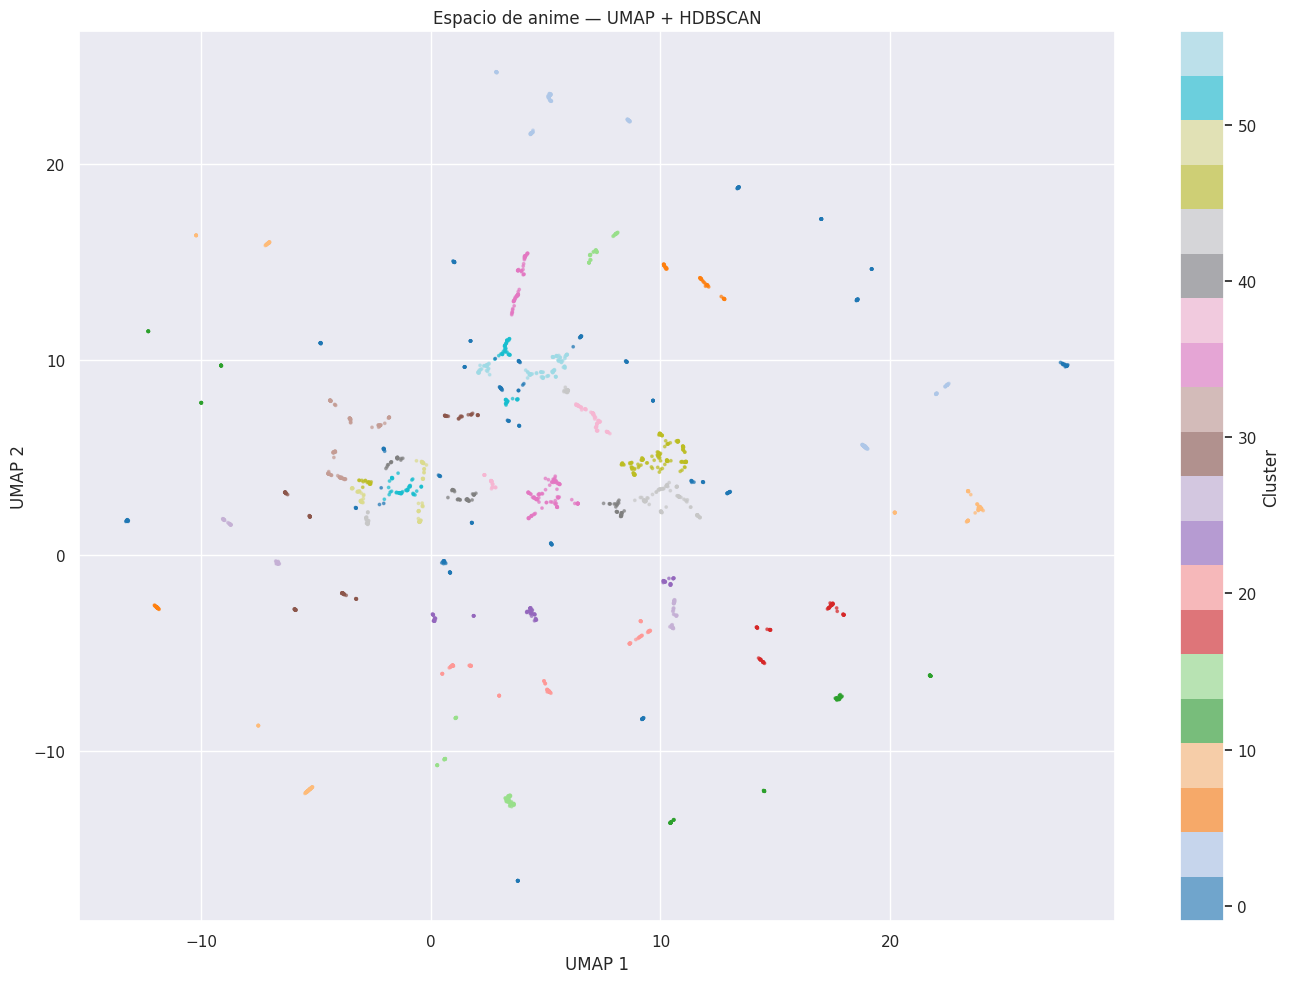

In [122]:
# Visualización de los cluster creados
fig, ax = plt.subplots(figsize=(14, 10))
scatter = ax.scatter(
    df_anime['umap_x'],
    df_anime['umap_y'],
    c=df_anime['cluster'],
    cmap='tab20',
    s=3,
    alpha=0.6
)
ax.set_title('Espacio de anime — UMAP + HDBSCAN')
ax.set_xlabel('UMAP 1')
ax.set_ylabel('UMAP 2')
plt.colorbar(scatter, ax=ax, label='Cluster')
plt.tight_layout()
plt.show()

In [123]:
## Conjunto de títulos representativos de cada cluster
for c in sorted(df_anime['cluster'].unique()):
    if c == -1:
        continue
    muestra = df_anime[df_anime['cluster'] == c]['title'].head(5).tolist()
    print(f"Cluster {c}: {muestra}")

Cluster 0: ['Barakamon', 'Non Non Biyori Nonstop', 'Usagi Drop', 'Non Non Biyori Repeat', 'Ruri no Houseki']
Cluster 1: ['Yuru Camp△ Season 2', 'Yahari Ore no Seishun Love Comedy wa Machigatteiru. Kan', 'Yuru Camp△', 'Yahari Ore no Seishun Love Comedy wa Machigatteiru. Zoku', 'Ouran Koukou Host Club']
Cluster 2: ['Chiikawa', 'Kaoru Hana wa Rin to Saku', 'Chihayafuru 3', 'Chihayafuru 2', 'Cross Game']
Cluster 3: ['Haikyuu!! Karasuno Koukou vs. Shiratorizawa Gakuen Koukou', 'Haikyuu!! Second Season', 'Haikyuu!! To the Top Part 2', 'Haikyuu!!', 'Haikyuu!! To the Top']
Cluster 4: ['Sasaki to Miyano', 'Horimiya', 'Ao no Hako', 'Horimiya: Piece', 'Tsuki ga Kirei']
Cluster 5: ['3-gatsu no Lion 2nd Season', 'Ikoku Nikki', 'Chi. Chikyuu no Undou ni Tsuite', 'Uma Musume: Cinderella Gray Part 2', 'Ping Pong the Animation']
Cluster 6: ['Shouwa Genroku Rakugo Shinjuu: Sukeroku Futatabi-hen', 'Shouwa Genroku Rakugo Shinjuu', 'Medalist 2nd Season', 'Medalist', 'Girls Band Cry']
Cluster 7: ['Great Tea

In [124]:
## 1. Identifica los géneros y scores
## 2. Ajusta los pesos dinámicos
## 3. Recupera candidatos con FAISS
## 4. Fusiona rankings con RRF
## 5. Aplica filtros semanticos
## 6. Rerank final y diversidad de anime por cluster
def recomendar_anime(titulo, df_pelser=df_pelser, k=5):
    """
    Genera recomendaciones de anime a partir de una película/serie occidental.
    """

    pelicula = df_pelser[df_pelser['título'].str.contains(titulo, case=False, na=False)]
    if pelicula.empty:
        print(f" No encontrada: {titulo}")
        return

    row = pelicula.iloc[0]
    gen_query = to_set(row['genres_clean'])
    FAMILY_GENRES = {'Family', 'Kids', 'Animation'}

    is_horror = 'Horror' in gen_query
    if not is_horror and float(row.get('horror_score', 0)) > 0.2:
        is_horror = True

    is_crime     = 'Crime'     in gen_query

    is_family = bool(gen_query & FAMILY_GENRES)
    if is_family and 'Family' not in gen_query and 'Kids' not in gen_query:
        if float(row.get('dark_score', 0)) > 0.1 or float(row.get('drama_score', 0)) > 0.4:
            is_family = False

    is_action    = 'Action'    in gen_query
    is_adventure = 'Adventure' in gen_query
    is_scifi     = 'Sci-Fi'    in gen_query
    is_fantasy   = 'Fantasy'   in gen_query

    is_meta = bool(gen_query & {'Parody', 'Gag Humor'})
    if not is_meta and float(row.get('meta_score', 0)) > 0.3:
        is_meta = True

    is_thriller  = bool(gen_query & {'Thriller', 'Mystery', 'Suspense'})
    is_dystopia  = float(row.get('dystopia_score', 0)) > 0.3
    is_power     = float(row.get('power_score',   0)) > 0.3
    is_music     = float(row.get('music_score',   0)) > 0.3

    is_romance = bool(gen_query & {'Romance', 'Drama'}) and not is_horror and not is_crime
    if is_romance and 'Romance' not in gen_query and float(row.get('romance', 0)) < 0.5:
        is_romance = False
    if not is_romance and float(row.get('romance', 0)) > 0.4:
        is_romance = True

    is_drama = 'Drama' in gen_query and float(row.get('drama_score', 0)) > 0.4 and not is_romance and not is_horror
    if is_power and float(row.get('power_score', 0)) > float(row.get('drama_score', 0)) * 0.8:
        is_drama = False
    if is_music:
        is_drama = False

    is_comedy = 'Comedy' in gen_query and float(row.get('comedy_score', 0)) > 0.3
    if is_drama and float(row.get('drama_score', 0)) > float(row.get('comedy_score', 0)):
        is_comedy = False

    is_infantil = is_family and (
        float(row.get('feel_good_score', 0)) > 0.5 or
        float(row.get('family_score',    0)) > 0.3
    )

    if is_horror or is_crime:
        peso_scores_idx, peso_embed_idx = 0.70, 0.30
    elif is_meta or is_thriller:
        peso_scores_idx, peso_embed_idx = 0.65, 0.35
    elif is_dystopia:
        peso_scores_idx, peso_embed_idx = 0.60, 0.40
    elif is_power:
        peso_scores_idx, peso_embed_idx = 0.55, 0.45
    elif is_music:
        peso_scores_idx, peso_embed_idx = 0.55, 0.45
    elif is_action or is_adventure or is_scifi or is_fantasy:
        peso_scores_idx, peso_embed_idx = 0.50, 0.50
    elif is_comedy or is_drama or is_romance:
        peso_scores_idx, peso_embed_idx = 0.40, 0.60
    else:
        peso_scores_idx, peso_embed_idx = 0.20, 0.80

    vec_scores = np.array(row['vector_scores'], dtype='float32').reshape(1, -1)
    faiss.normalize_L2(vec_scores)
    vec_embed = np.array(row['embedding'], dtype='float32').reshape(1, -1)
    faiss.normalize_L2(vec_embed)

    top_k = 400 if (is_dystopia or is_power or is_music or is_horror) else 200
    _, i_scores = index_scores.search(vec_scores, top_k)
    _, i_embed  = index_embed.search(vec_embed,   top_k)

    rrf_scores = defaultdict(float)
    k_rrf = 60
    for rank, idx in enumerate(i_scores[0]):
        rrf_scores[idx] += peso_scores_idx / (k_rrf + rank + 1)
    for rank, idx in enumerate(i_embed[0]):
        rrf_scores[idx] += peso_embed_idx  / (k_rrf + rank + 1)

    if is_dystopia:
        for anime_idx in df_anime[df_anime['dystopia_score'] >= 0.4].index:
            rrf_scores[anime_idx] += 0.015

    if is_power:
        for anime_idx in df_anime[df_anime['power_score'] >= 0.35].index:
            rrf_scores[anime_idx] += 0.010

    if is_music:
        for anime_idx in df_anime[df_anime['music_score'] >= 0.5].index:
            rrf_scores[anime_idx] += 0.012

    if is_horror and float(row.get('horror_score', 0)) < 0.5:
        for anime_idx in df_anime[df_anime['horror_score'] >= 0.5].index:
            rrf_scores[anime_idx] += 0.010

    if is_fantasy and float(row.get('fantasy', 0)) > 0.6:
        for anime_idx in df_anime[
            (df_anime['fantasy'] >= 0.7) &
            (df_anime['adventure_score'] >= 0.5)
        ].index:
            rrf_scores[anime_idx] += 0.012

    if is_action and is_comedy:
        for anime_idx in df_anime[
            (df_anime['meta_score'] >= 0.5) &
            (df_anime['action_score'] >= 0.5)
        ].index:
            rrf_scores[anime_idx] += 0.015

    candidatos = sorted(rrf_scores.keys(), key=lambda x: rrf_scores[x], reverse=True)
    rrf_vals   = [rrf_scores[idx] for idx in candidatos]

    umbral_family = 0.30
    for intento in range(3):
        candidatos_f, scores_f = [], []
        for idx, fscore in zip(candidatos, rrf_vals):
            anime     = df_anime.iloc[idx]
            gen_anime = (to_set(anime['genres_clean']) |
                         to_set(anime.get('themes'))   |
                         to_set(anime.get('demographic')))

            if is_family   and any(g in gen_anime for g in ['Ecchi', 'Hentai', 'Gore']): continue
            if is_horror   and 'Kids' in gen_anime:                                       continue
            if is_romance  and anime['horror_score'] > 0.5:                               continue
            if (is_action or is_adventure) and not is_horror and anime['horror_score'] > 0.6: continue
            if is_meta     and anime.get('comedy_score', 0) < 0.1:                        continue
            if is_thriller and 'Kids' in gen_anime:                                       continue
            if is_comedy   and not is_family and anime['family_score'] > 0.8:             continue
            if is_infantil and anime['family_score'] < umbral_family:                     continue
            if is_infantil and any(g in gen_anime for g in ['Seinen', 'Josei']):          continue
            if is_crime    and anime['crime_score'] < 0.15 and anime['dark_score'] < 0.2: continue
            if is_power    and anime.get('power_score', 0) < 0.35:                        continue
            if is_power    and anime['crime_score'] > 0.5 and anime['dark_score'] < 0.2: continue
            if is_music    and anime.get('music_score', 0) < 0.5:                         continue
            if is_drama    and not is_romance and anime.get('romance', 0) > 0.8 and anime.get('drama_score', 0) < 0.4: continue
            if is_action   and is_comedy and not is_family and anime.get('comedy_score', 0) < 0.3: continue

            candidatos_f.append(idx)
            scores_f.append(fscore)
            if len(candidatos_f) >= k * 10:
                break

        if len(candidatos_f) >= k:
            break
        umbral_family -= 0.10

    reranked = rerank(row, candidatos_f, scores_f)

    MAX_POR_CLUSTER = 3 if (is_dystopia or is_power or is_music) else 2
    vistos_titulos  = set()
    cluster_counts  = Counter()
    recomendaciones = []

    for idx in reranked:
        anime   = df_anime.iloc[idx]
        base    = limpiar_titulo_base(anime['title'])
        cluster = int(anime.get('cluster', -1))

        if base in vistos_titulos:
            continue
        if cluster != -1 and cluster_counts[cluster] >= MAX_POR_CLUSTER:
            continue

        vistos_titulos.add(base)
        cluster_counts[cluster] += 1
        recomendaciones.append(idx)

        if len(recomendaciones) >= k:
            break

    print(f"\n Película/serie: {row['título']}")
    print(f"   music={row.get('music_score',0):.2f} | power={row.get('power_score',0):.2f} | dystopia={row.get('dystopia_score',0):.2f}")
    print(f" Animes recomendados:\n")
    for i, idx in enumerate(recomendaciones):
        anime = df_anime.iloc[idx]
        print(f"{i+1}. {anime['title']} — "
              f"fantasy: {anime.get('fantasy', 0):.2f} | "
              f"adventure: {anime['adventure_score']:.2f} | "
              f"horror: {anime['horror_score']:.2f} | "
              f"cluster: {int(anime.get('cluster', -1))}")

In [125]:
## Títulos de referencia para saber si fue ejecutado de manera correcta el modelo
for titulo in [ "Breaking Bad", "El Conjuro",
               "Diario de una pasión", "juegos del hambre"]:
    recomendar_anime(titulo, k=5)
    print("─" * 50)


 Película/serie: Breaking Bad
   music=0.10 | power=0.50 | dystopia=0.00
 Animes recomendados:

1. Texhnolyze — fantasy: 0.00 | adventure: 0.10 | horror: 0.40 | cluster: 37
2. Mousou Dairinin — fantasy: 0.30 | adventure: 0.00 | horror: 0.60 | cluster: 53
3. Banana Fish — fantasy: 0.20 | adventure: 0.70 | horror: 0.30 | cluster: 54
4. 91 Days — fantasy: 0.00 | adventure: 0.20 | horror: 0.10 | cluster: 54
5. Odd Taxi — fantasy: 0.00 | adventure: 0.00 | horror: 0.20 | cluster: 53
──────────────────────────────────────────────────

 Película/serie: El Conjuro
   music=0.00 | power=0.10 | dystopia=0.00
 Animes recomendados:

1. Shiki Specials — fantasy: 0.45 | adventure: 0.10 | horror: 1.00 | cluster: 56
2. Mononoke Movie 2: Hinezumi — fantasy: 0.50 | adventure: 0.00 | horror: 0.90 | cluster: 56
3. Higurashi no Naku Koro ni — fantasy: 0.00 | adventure: 0.00 | horror: 0.85 | cluster: -1
4. Danganronpa 3: The End of Kibougamine Gakuen - Kibou-hen — fantasy: 0.00 | adventure: 0.20 | horror: 0

In [126]:
## Validación del modelo secundario
print(f"Clusters encontrados : {n_clusters}")
# Silhouette y Davies-Bouldin
from sklearn.metrics import silhouette_score, davies_bouldin_score

mask         = df_anime['cluster'] != -1
coords_clean = coords[mask]
labels_clean = df_anime.loc[mask, 'cluster'].values

sil = silhouette_score(coords_clean, labels_clean, sample_size=1000)
db  = davies_bouldin_score(coords_clean, labels_clean)
print(f"\nSilhouette Score     : {sil:.3f}  (ideal > 0.3)")
print(f"Davies-Bouldin Score : {db:.3f}   (ideal < 1.0)")

# Todos los clusters
print(f"\nTodos los clusters:")
for cluster_id in sorted(df_anime['cluster'].unique()):
    if cluster_id == -1: continue
    subset  = df_anime[df_anime['cluster'] == cluster_id]
    generos = subset['genres'].explode().value_counts().head(3)
    print(f"  Cluster {cluster_id:2d} ({len(subset):3d} animes): {', '.join(generos.index.tolist())}")

Clusters encontrados : 57

Silhouette Score     : 0.675  (ideal > 0.3)
Davies-Bouldin Score : 0.461   (ideal < 1.0)

Todos los clusters:
  Cluster  0 ( 22 animes): Slice of Life, Iyashikei, CGDCT
  Cluster  1 ( 52 animes): School, Romance, Comedy
  Cluster  2 ( 78 animes): School, Drama, Slice of Life
  Cluster  3 ( 40 animes): School, Sports, Shounen
  Cluster  4 ( 25 animes): School, Romance, Shoujo
  Cluster  5 ( 35 animes): Drama, Seinen, Sports
  Cluster  6 ( 20 animes): Drama, Music, Performing Arts
  Cluster  7 ( 24 animes): Comedy, School, Shounen
  Cluster  8 ( 51 animes): Comedy, Shounen, Anthropomorphic
  Cluster  9 ( 76 animes): Fantasy, Adventure, Action
  Cluster 10 ( 30 animes): Music, Performing Arts, Mahou Shoujo
  Cluster 11 ( 33 animes): Adventure, Fantasy, Comedy
  Cluster 12 ( 23 animes): School, Shounen, Romance
  Cluster 13 ( 47 animes): Drama, Mecha, Sci-Fi
  Cluster 14 ( 43 animes): Comedy, Action, Shounen
  Cluster 15 ( 61 animes): Action, Adventure, Fantasy
 

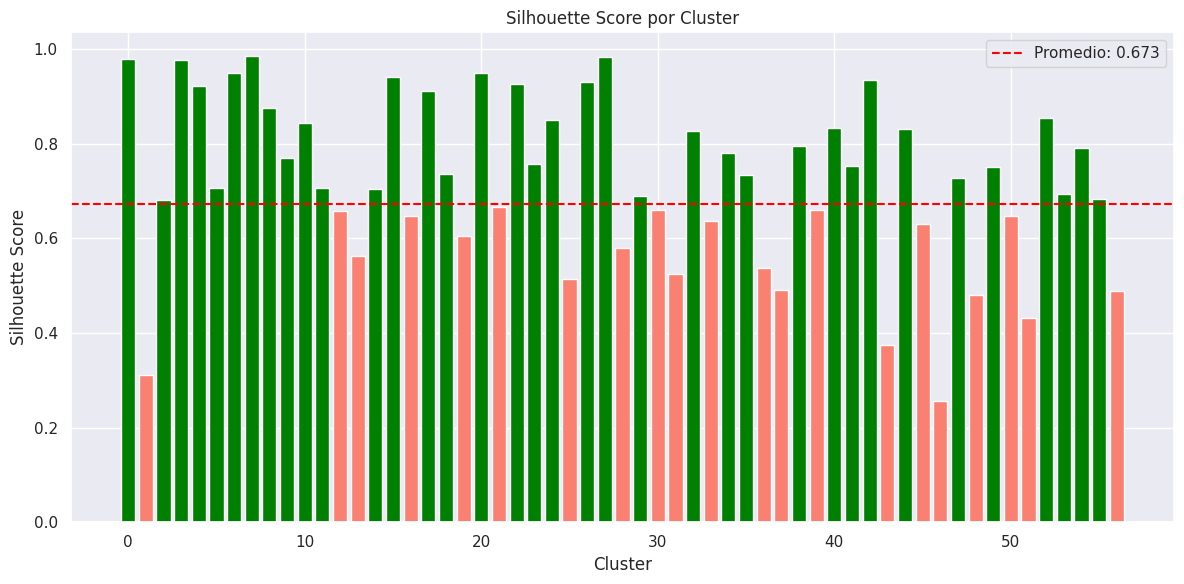

In [127]:
## Silhouette score
mask         = df_anime['cluster'] != -1
labels_clean = df_anime.loc[mask, 'cluster'].values
coords_clean = coords[mask]

from sklearn.metrics import silhouette_samples
sil_vals = silhouette_samples(coords_clean, labels_clean)

# Silhouette promedio por cluster
clusters  = sorted(np.unique(labels_clean))
sil_means = [sil_vals[labels_clean == c].mean() for c in clusters]
sil_avg   = np.mean(sil_vals)

plt.figure(figsize=(12, 6))
colores = ['green' if s >= sil_avg else 'salmon' for s in sil_means]
plt.bar(clusters, sil_means, color=colores)
plt.axhline(y=sil_avg, color='red', linestyle='--', label=f'Promedio: {sil_avg:.3f}')
plt.xlabel('Cluster')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Score por Cluster')
plt.legend()
plt.tight_layout()
plt.show()

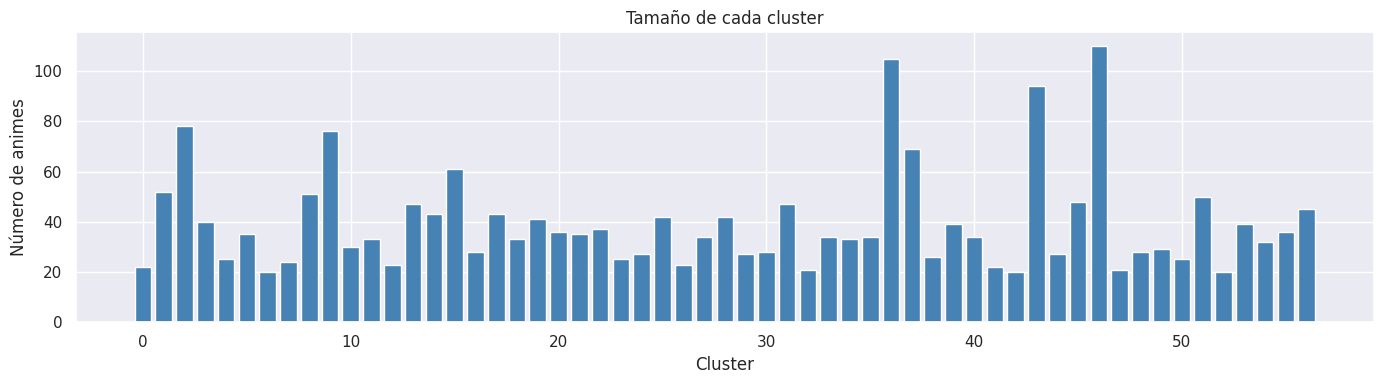

In [128]:
## Gráfica para analizar el tamaño de cada cluster
sizes = df_anime[df_anime['cluster'] != -1]['cluster'].value_counts().sort_index()
plt.figure(figsize=(14, 4))
plt.bar(sizes.index, sizes.values, color='steelblue')
plt.xlabel('Cluster')
plt.ylabel('Número de animes')
plt.title('Tamaño de cada cluster')
plt.tight_layout()
plt.show()

#### Hallazgos para modelación

**Hallazgos clave Modelo FAISS:**


*   Se construyen dos índices FAISS paralelos: uno sobre vector_scores (temático-narrativo) y otro sobre embedding (semántico de sinopsis).
* La función recomendar_anime combina ambos índices mediante Reciprocal Rank Fusion (RRF), balanceando la similitud estructural con la similitud textual.
* La función rerank aplica un post-filtro de reglas narrativas que penaliza o bonifica candidatos según coherencia temática (ej. si la consulta es familiar, se penalizan los anime gore).
* Validación de coherencia temática: la precisión temática del índice de scores superó al de embeddings, confirmando que los scores narrativos mejoran la recuperación de contenido similar.

**Hallazgos clave Modelo UMAP+HDBSCAN**
* La reducción de dimensionalidad con UMAP proyecta los vectores de alta dimensión a 2D preservando la estructura local de similitud coseno.
* HDBSCAN encontró múltiples clusters temáticos sin necesidad de especificar el número de grupos a priori.
* El Silhouette Score evaluó la cohesión y separación de clusters. El Davies-Bouldin Score complementó la evaluación de compacidad.
Los clusters se usan para garantizar diversidad en las recomendaciones finales: el modelo evita recomendar cinco anime del mismo cluster.


**Hallazgo final**
* El uso de dos índices FAISS con fusión RRF + rerank narrativo es un diseño profesional que balancea precisión semántica con coherencia temática. El modelo secundario (UMAP+HDBSCAN) añade diversidad a las recomendaciones, resolviendo un problema clásico de los sistemas recomendadores.


# 4. Conclusión

**Conclusiones generales.**

* El proyecto logra su objetivo central: conectar dos universos de contenido que normalmente no se comparan, usando representaciones vectoriales compartidas en lugar de metadatos explícitos comunes.
* El proyecto demuestra que es posible construir un puente semántico entre géneros cinematográficos occidentales y anime mediante representaciones vectoriales ricas, sin necesidad de datos de interacción de usuarios ni sistemas de filtrado colaborativo.
* La combinación de dos fuentes de datos heterogéneas (MyAnimeList y TMDB) permitió construir un catálogo robusto que cubre tanto el dominio de consulta como el dominio de resultados.
* Las validaciones cuantitativas aplicadas (precisión temática, self-retrieval al 100%, Silhouette Score y Davies-Bouldin Score) confirman que tanto los índices FAISS como los clusters de HDBSCAN son coherentes y deterministas.

**Limitaciones**
* El sistema no cuenta con retroalimentación de usuarios reales, por lo que los pesos del rerank y los scores narrativos fueron calibrados manualmente.
* Los diccionarios de mapeo de géneros (español → inglés, temas → géneros base) fueron construidos manualmente y pueden no cubrir todos los casos posibles, especialmente géneros emergentes o nomenclaturas regionales.
* Las sinopsis de TMDB son significativamente más cortas y genéricas que las de MAL, lo que genera asimetría en la calidad de los embeddings entre el dominio de consulta y el dominio de resultados.
* La detección de contenido para adultos se basa en filtros por palabras clave y etiquetas, lo que puede generar falsos negativos con títulos ambiguos o sin etiquetar correctamente.

**Trabajo futuro y posibles mejoras**
* Implementar un módulo de retroalimentación explícita (me gustó / no me gustó) dentro de la aplicación Streamlit para recopilar datos reales de preferencia y ajustar los pesos del rerank de forma supervisada.
* Incorporar personalización por historial de usuario, construyendo un perfil vectorial promedio a partir de las obras que el usuario ha calificado positivamente, para adaptar las recomendaciones a sus preferencias acumuladas.



**El proyecto logra su objetivo principal:**

Construir un sistema funcional y bien fundamentado que permite a un usuario ingresar una película o serie que conoce y recibir recomendaciones de anime temáticamente equivalentes. La solución va más allá de un recomendador basado en géneros simples; integra semántica de lenguaje natural, representaciones estructuradas y reglas narrativas en un pipeline coherente y exportable a producción.

## Guardar para streamlit

In [129]:
#df_anime.to_parquet('df_anime_final.parquet')
#df_pelser.to_parquet('df_pelser_final.parquet')
#faiss.write_index(index_scores, 'index_scores.faiss')
#faiss.write_index(index_embed,  'index_embed.faiss')

#import os
#for f in ['df_anime_final.parquet', 'df_pelser_final.parquet',
 #        'index_scores.faiss', 'index_embed.faiss']:
  #  size = os.path.getsize(f) / 1024 / 1024
   # print(f" {f}: {size:.1f} MB")

#from google.colab import files
#for f in ['df_anime_final.parquet', 'df_pelser_final.parquet',
 #        'index_scores.faiss', 'index_embed.faiss']:
  #  files.download(f)